In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/data.csv
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_md_20x_304.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_bd_40x_301.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_bd_40x_17.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_pd_40x_301.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_bd_20x_404.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_bd_40x_67.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_md_40x_100.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_bd_20x_9.jpg
/kaggle/input/datasets/abd

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdullahhasansajjad/lunghist700")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/abdullahhasansajjad/lunghist700


In [3]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets"):
    print(root)
    print("Directories:", dirs)
    print("Files:", files[:5])
    print("-"*70)

/kaggle/input/datasets
Directories: ['abdullahhasansajjad', 'rm1000']
Files: []
----------------------------------------------------------------------
/kaggle/input/datasets/abdullahhasansajjad
Directories: ['lunghist700']
Files: []
----------------------------------------------------------------------
/kaggle/input/datasets/abdullahhasansajjad/lunghist700
Directories: ['LungHist700_combined']
Files: []
----------------------------------------------------------------------
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined
Directories: ['data']
Files: []
----------------------------------------------------------------------
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data
Directories: ['images']
Files: ['data.csv']
----------------------------------------------------------------------
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images
Directories: ['aca', 'ssc', 'nor']
Files: []
--------------

In [4]:
class_to_idx = {
    "aca": 0,
    "nor": 1,
    "ssc": 2
}

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rm1000/lung-cancer-histopathological-images


In [6]:
import os
from PIL import Image
from torch.utils.data import Dataset

class LungHist700Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples = []

        class_map = {
            "aca": 0,   # Adenocarcinoma
            "nor": 1,   # Normal (Benign)
            "ssc": 2    # Squamous Cell Carcinoma
        }

        for folder, label in class_map.items():
            folder_path = os.path.join(root_dir, folder)

            for img_name in os.listdir(folder_path):
                if img_name.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append(
                        (os.path.join(folder_path, img_name), label)
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
lung700_path = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images"

In [7]:
external_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
])

NameError: name 'transforms' is not defined

In [8]:
# ===========================================
# MGAF-SwinEff
# Cell 1 : Imports
# ===========================================

import os
import cv2
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# CNN Backbone
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

IMG_SIZE = (224,224)
NUM_CLASSES = 3
BATCH_SIZE = 32

print("TensorFlow :", tf.__version__)
print("Num GPUs :", len(tf.config.list_physical_devices('GPU')))

TensorFlow : 2.20.0
Num GPUs : 2


In [9]:
!pip install -q transformers timm

In [10]:
import tensorflow as tf
import keras

print(tf.__version__)
print(keras.__version__)
import transformers
print(transformers.__version__)

2.20.0
3.13.2
5.0.0


In [11]:
import tensorflow as tf
from tensorflow.keras import layers

# --------------------------------------------------
# Channel Attention
# --------------------------------------------------

class ChannelAttention(layers.Layer):

    def __init__(self, ratio=8):
        super().__init__()
        self.ratio = ratio

    def build(self, input_shape):

        channels = input_shape[-1]

        self.gap = layers.GlobalAveragePooling2D()

        self.fc1 = layers.Dense(
            channels // self.ratio,
            activation='relu'
        )

        self.fc2 = layers.Dense(
            channels,
            activation='sigmoid'
        )

    def call(self, x):

        att = self.gap(x)

        att = self.fc1(att)

        att = self.fc2(att)

        att = tf.reshape(att, (-1,1,1,x.shape[-1]))

        return x * att

In [12]:
# --------------------------------------------------
# Spatial Attention
# --------------------------------------------------

class SpatialAttention(layers.Layer):

    def __init__(self):
        super().__init__()

        self.conv = layers.Conv2D(
            1,
            kernel_size=7,
            padding="same",
            activation="sigmoid"
        )

    def call(self, x):

        avg = tf.reduce_mean(x, axis=-1, keepdims=True)

        mx = tf.reduce_max(x, axis=-1, keepdims=True)

        feat = tf.concat([avg,mx], axis=-1)

        att = self.conv(feat)

        return x * att

In [13]:
# --------------------------------------------------
# Modified Global Attention Fusion
# --------------------------------------------------

class MGAF(layers.Layer):

    def __init__(self, filters=512):

        super().__init__()

        self.ca = ChannelAttention()

        self.sa = SpatialAttention()

        self.conv1 = layers.Conv2D(
            filters,
            1,
            padding="same"
        )

        self.bn = layers.BatchNormalization()

        self.relu = layers.ReLU()

    def call(self, cnn, transformer):

        cnn = self.ca(cnn)

        transformer = self.sa(transformer)

        fused = tf.concat(
            [cnn, transformer],
            axis=-1
        )

        fused = self.conv1(fused)

        fused = self.bn(fused)

        fused = self.relu(fused)

        return fused

In [14]:
# --------------------------------------------------
# Dual Attention GAF
# --------------------------------------------------

class DAGAF(layers.Layer):

    def __init__(self, filters=512):

        super().__init__()

        self.ca = ChannelAttention()

        self.sa = SpatialAttention()

        self.cross = layers.MultiHeadAttention(
            num_heads=4,
            key_dim=64
        )

        self.conv = layers.Conv2D(
            filters,
            1,
            padding="same"
        )

        self.bn = layers.BatchNormalization()

        self.relu = layers.ReLU()

    def call(self, cnn, transformer):

        cnn = self.ca(cnn)

        transformer = self.sa(transformer)

        B = tf.shape(cnn)[0]

        H = cnn.shape[1]

        W = cnn.shape[2]

        C = cnn.shape[3]

        cnn_seq = tf.reshape(cnn,(B,H*W,C))

        trans_seq = tf.reshape(transformer,(B,H*W,C))

        cross = self.cross(
            cnn_seq,
            trans_seq
        )

        cross = tf.reshape(
            cross,
            (B,H,W,C)
        )

        fused = tf.concat(
            [cnn,transformer,cross],
            axis=-1
        )

        fused = self.conv(fused)

        fused = self.bn(fused)

        fused = self.relu(fused)

        return fused

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rm1000/lung-cancer-histopathological-images


In [16]:
# ==============================
# CONFIGURATION
# ==============================

DATASET_PATH = "/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images"

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_CLASSES = 3

NUM_WORKERS = 2

In [17]:
# ============================================================
# PART 1
# Data Pipeline + ConvNeXt Tiny + Swin Tiny Backbones
# ============================================================

import os
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [18]:
!pip install staintools spams-bin

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 13.9 MB/s eta 0:00:0000:0100:01
  Created wheel for staintools: filename=staintools-2.1.2-py3-none-any.whl size=14079 sha256=06ef69f98fd889c07cede40876e1475dc19fcd58120d997c2134ee728284065a
  Stored in directory: /root/.cache/pip/wheels/4d/ae/02/336aa637aaa26e83b7baa062700b6e39aa1378aaa930195afa
Successfully built staintools


In [19]:
import staintools
import cv2
import numpy as np
from PIL import Image

In [18]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [19]:
import os

DATASET_PATH = "/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images"

for root, dirs, files in os.walk(DATASET_PATH):
    print(root)
    for d in dirs:
        print("   ", d)
    break

/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images
    squamous_cell_carcinoma
    benign
    adenocarcinoma


In [20]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# ==============================
# Load Full Dataset
# ==============================

full_dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=train_transform


)

print("Classes:", full_dataset.classes)
print("Total Images:", len(full_dataset))

Classes: ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']
Total Images: 15000


In [21]:
# 70% Train
# 15% Validation
# 15% Test

train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

10500
2250
2250


In [22]:
full_train = datasets.ImageFolder(
    DATASET_PATH,
    transform=train_transform
)

full_eval = datasets.ImageFolder(
    DATASET_PATH,
    transform=val_transform
)

indices = torch.randperm(len(full_train), generator=torch.Generator().manual_seed(42))

train_size = int(0.70 * len(indices))
val_size = int(0.15 * len(indices))

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size+val_size]
test_idx = indices[train_size+val_size:]

from torch.utils.data import Subset

train_dataset = Subset(full_train, train_idx)
val_dataset = Subset(full_eval, val_idx)
test_dataset = Subset(full_eval, test_idx)

In [24]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [25]:
print("Classes:", full_train.classes)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

Classes: ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']
Train: 10500
Validation: 2250
Test: 2250
torch.Size([32, 3, 224, 224])
torch.Size([32])


In [26]:
from torchvision import datasets
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

import numpy as np

In [27]:
DATASET_PATH = "/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images"

train_dataset_full = datasets.ImageFolder(
    DATASET_PATH,
    transform=train_transform
)

eval_dataset_full = datasets.ImageFolder(
    DATASET_PATH,
    transform=val_transform
)

targets = np.array(train_dataset_full.targets)

indices = np.arange(len(targets))

print(train_dataset_full.classes)
print(len(indices))

['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']
15000


In [28]:
NUM_FOLDS = 5

skf = StratifiedKFold(
    n_splits=NUM_FOLDS,
    shuffle=True,
    random_state=42
)

In [29]:
images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

In [30]:
import torch
import torch.nn as nn

class ChannelAttention(nn.Module):

    def __init__(self, channels, reduction=16):

        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))

        attention = self.sigmoid(avg_out + max_out)

        return x * attention

In [31]:
class SpatialAttention(nn.Module):

    def __init__(self, kernel_size=7):

        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size,
            padding=padding,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg = torch.mean(x, dim=1, keepdim=True)

        mx, _ = torch.max(x, dim=1, keepdim=True)

        attention = self.sigmoid(
            self.conv(
                torch.cat([avg, mx], dim=1)
            )
        )

        return x * attention

In [32]:
x = torch.randn(4,768,7,7)

ca = ChannelAttention(768)

sa = SpatialAttention()

print(ca(x).shape)

print(sa(x).shape)

torch.Size([4, 768, 7, 7])
torch.Size([4, 768, 7, 7])


In [33]:
class MSDGAF(nn.Module):

    def __init__(self, channels):

        super().__init__()

        # -----------------------------------
        # Multi-scale feature extractor
        # -----------------------------------

        self.dw3 = nn.Conv2d(
            channels * 2,
            channels * 2,
            kernel_size=3,
            padding=1,
            groups=channels * 2,
            bias=False
        )

        self.dw5 = nn.Conv2d(
            channels * 2,
            channels * 2,
            kernel_size=5,
            padding=2,
            groups=channels * 2,
            bias=False
        )

        self.pointwise = nn.Sequential(

            nn.Conv2d(
                channels * 4,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(channels),

            nn.GELU()
        )

        # -----------------------------------
        # Dynamic Gate
        # -----------------------------------

        self.gate = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(channels),

            nn.Sigmoid()

        )

        # -----------------------------------
        # Residual Refinement
        # -----------------------------------

        self.refine = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(channels),

            nn.GELU()

        )

    def forward(self, conv_feat, swin_feat):

        # concatenate

        fusion = torch.cat(
            [conv_feat, swin_feat],
            dim=1
        )

        # multi-scale

        feat3 = self.dw3(fusion)

        feat5 = self.dw5(fusion)

        fusion = torch.cat(
            [feat3, feat5],
            dim=1
        )

        fusion = self.pointwise(fusion)

        # dynamic gate

        gate = self.gate(fusion)

        fused = (
            gate * conv_feat
            +
            (1 - gate) * swin_feat
        )

        # residual fusion

        fused = fused + conv_feat + swin_feat

        fused = self.refine(fused)

        return fused

In [34]:
x1 = torch.randn(2,768,7,7)

x2 = torch.randn(2,768,7,7)

fusion = MSDGAF(768)

y = fusion(x1,x2)

print(y.shape)

torch.Size([2, 768, 7, 7])


In [35]:
import torch
import torch.nn as nn

class CGMSDGAF(nn.Module):

    def __init__(self, channels):

        super().__init__()

        # ---------- Cross Gate ----------

        self.conv_gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // 16, 1, bias=False),
            nn.GELU(),
            nn.Conv2d(channels // 16, channels, 1, bias=False),
            nn.Sigmoid()
        )

        self.swin_gate = nn.Sequential(
            nn.Conv2d(channels, 1, kernel_size=7, padding=3, bias=False),
            nn.Sigmoid()
        )

        # ---------- Multi-scale ----------

        self.dw3 = nn.Conv2d(
            channels * 2,
            channels * 2,
            kernel_size=3,
            padding=1,
            groups=channels * 2,
            bias=False
        )

        self.dw5 = nn.Conv2d(
            channels * 2,
            channels * 2,
            kernel_size=5,
            padding=2,
            groups=channels * 2,
            bias=False
        )

        self.project = nn.Sequential(

            nn.Conv2d(
                channels * 4,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(channels),

            nn.GELU()

        )

        # ---------- Refinement ----------

        self.refine = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(channels),

            nn.GELU()

        )

    def forward(self, conv_feat, swin_feat):

        # ---------------------------------
        # Cross Guidance
        # ---------------------------------

        channel_gate = self.conv_gate(conv_feat)

        spatial_gate = self.swin_gate(swin_feat)

        guided_swin = swin_feat * channel_gate

        guided_conv = conv_feat * spatial_gate

        # ---------------------------------
        # Feature Fusion
        # ---------------------------------

        fusion = torch.cat(
            [guided_conv, guided_swin],
            dim=1
        )

        multi3 = self.dw3(fusion)

        multi5 = self.dw5(fusion)

        fusion = torch.cat(
            [multi3, multi5],
            dim=1
        )

        fusion = self.project(fusion)

        # ---------------------------------
        # Residual
        # ---------------------------------

        fusion = fusion + guided_conv + guided_swin

        fusion = self.refine(fusion)

        return fusion

In [36]:
x1 = torch.randn(4,768,7,7)

x2 = torch.randn(4,768,7,7)

module = CGMSDGAF(768)

y = module(x1,x2)

print(y.shape)

torch.Size([4, 768, 7, 7])


In [37]:
class FeatureAlignment(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.align = nn.Sequential(

            nn.Conv2d(channels, channels, 1, bias=False),

            nn.BatchNorm2d(channels),

            nn.GELU()

        )

    def forward(self, x):

        return self.align(x)

In [38]:
class ClassificationHead(nn.Module):

    def __init__(self, channels=768, hidden=256, num_classes=3):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(channels, hidden)

        self.relu = nn.ReLU(inplace=True)

        self.dropout = nn.Dropout(0.4)

        self.fc2 = nn.Linear(hidden, num_classes)

    def forward(self, x, return_features=False):

        x = self.pool(x)

        x = self.flatten(x)

        features = self.fc1(x)

        features = self.relu(features)

        features = self.dropout(features)

        logits = self.fc2(features)

        if return_features:
            return logits, features

        return logits

In [39]:
class ConvNeXtSwinCGMSDGAF(nn.Module):

    def __init__(self, num_classes=3):

        super().__init__()

        self.convnext = ConvNeXtBackbone()

        self.swin = SwinBackbone()

        self.align_conv = FeatureAlignment(768)

        self.align_swin = FeatureAlignment(768)

        self.ca = ChannelAttention(768)

        self.sa = SpatialAttention()

        self.fusion = CGMSDGAF(768)

        self.head = ClassificationHead(
            channels=768,
            hidden=256,
            num_classes=num_classes
        )

    def forward(self, x):

        conv = self.convnext(x)

        swin = self.swin(x)

        conv = self.align_conv(conv)

        swin = self.align_swin(swin)

        conv = self.ca(conv)

        swin = self.sa(swin)

        fused = self.fusion(conv, swin)

        return self.head(fused)

    def extract_features(self, x):

        conv = self.convnext(x)

        swin = self.swin(x)

        conv = self.align_conv(conv)

        swin = self.align_swin(swin)

        conv = self.ca(conv)

        swin = self.sa(swin)

        fused = self.fusion(conv, swin)

        _, features = self.head(fused, return_features=True)

        return features

In [40]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import torch.nn as nn

class ConvNeXtBackbone(nn.Module):

    def __init__(self):
        super().__init__()

        model = convnext_tiny(
            weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )

        # Keep only the feature extractor
        self.features = model.features

    def forward(self, x):

        x = self.features(x)

        # Output shape: [B, 768, 7, 7]
        return x

In [41]:
from torchvision.models import swin_t, Swin_T_Weights
import torch.nn as nn

class SwinBackbone(nn.Module):

    def __init__(self):
        super().__init__()

        model = swin_t(
            weights=Swin_T_Weights.IMAGENET1K_V1
        )

        # Feature extractor only
        self.features = model.features

    def forward(self, x):

        x = self.features(x)

        # TorchVision Swin outputs NHWC
        # Convert to NCHW
        x = x.permute(0, 3, 1, 2).contiguous()

        return x

In [42]:
from torchvision.models import (
    convnext_tiny,
    ConvNeXt_Tiny_Weights,
    swin_t,
    Swin_T_Weights
)

conv = convnext_tiny(
    weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1
)

swin = swin_t(
    weights=Swin_T_Weights.IMAGENET1K_V1
)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 185MB/s]  


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 155MB/s]  


In [43]:
def forward(self, x):

    conv = self.convnext(x)
    print("ConvNeXt:", conv.shape)

    swin = self.swin(x)
    print("Swin:", swin.shape)

    conv = self.align_conv(conv)
    print("Aligned Conv:", conv.shape)

    swin = self.align_swin(swin)
    print("Aligned Swin:", swin.shape)

    conv = self.ca(conv)
    print("Channel Attention:", conv.shape)

    swin = self.sa(swin)
    print("Spatial Attention:", swin.shape)

    fused = self.fusion(conv, swin)
    print("Fusion:", fused.shape)

    out = self.head(fused)
    print("Output:", out.shape)

    return self.head(fused)

In [44]:
conv = ConvNeXtBackbone().to(device)
swin = SwinBackbone().to(device)

x = torch.randn(2,3,224,224).to(device)

print("Conv:", conv(x).shape)
print("Swin:", swin(x).shape)

Conv: torch.Size([2, 768, 7, 7])
Swin: torch.Size([2, 768, 7, 7])


In [45]:
model = ConvNeXtSwinCGMSDGAF(num_classes=3).to(device)

In [46]:
model = ConvNeXtSwinCGMSDGAF(num_classes=3).to(device)

dummy = torch.randn(2,3,224,224).to(device)

out = model(dummy)

print(out.shape)

torch.Size([2, 3])


In [47]:
def forward(self, x):

    conv = self.convnext(x)
    print("ConvNeXt:", conv.shape)

    swin = self.swin(x)
    print("Swin:", swin.shape)

    conv = self.align_conv(conv)
    print("Aligned Conv:", conv.shape)

    swin = self.align_swin(swin)
    print("Aligned Swin:", swin.shape)

    conv = self.ca(conv)
    print("Channel Attention:", conv.shape)

    swin = self.sa(swin)
    print("Spatial Attention:", swin.shape)

    fused = self.fusion(conv, swin)
    print("Fusion:", fused.shape)

    out = self.head(fused)
    print("Output:", out.shape)

    return out

In [48]:
print(model)

ConvNeXtSwinCGMSDGAF(
  (convnext): ConvNeXtBackbone(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2

In [49]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [50]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [51]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    T_mult=2,
    eta_min=1e-6
)

In [52]:
scaler = torch.amp.GradScaler("cuda")


In [53]:
with torch.amp.autocast(device_type="cuda"):
    outputs = model(images)
    loss = criterion(outputs, labels)

In [54]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0

    preds = []
    labels_list = []

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        pred = outputs.argmax(1)

        preds.extend(pred.cpu().numpy())

        labels_list.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)

    epoch_acc = accuracy_score(labels_list, preds)

    return epoch_loss, epoch_acc

In [55]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0

    preds = []
    labels_list = []
    probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = criterion(outputs, labels)

            running_loss += loss.item()

            pred = outputs.argmax(1)

            prob = torch.softmax(outputs,1)

            preds.extend(pred.cpu().numpy())

            probs.extend(prob.cpu().numpy())

            labels_list.extend(labels.cpu().numpy())

    return {

        "loss": running_loss/len(loader),

        "acc": accuracy_score(labels_list,preds),

        "precision": precision_score(labels_list,preds,average="macro"),

        "recall": recall_score(labels_list,preds,average="macro"),

        "f1": f1_score(labels_list,preds,average="macro"),

        "auc": roc_auc_score(
            labels_list,
            np.array(probs),
            multi_class="ovr"
        )

    }

In [56]:
NUM_EPOCHS = 20

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

import numpy as np
import torch


def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = criterion(outputs, labels)

            running_loss += loss.item()

            # ---------- Prediction ----------
            preds = outputs.argmax(dim=1)

            # ---------- Probability ----------
            probs = torch.softmax(outputs.float(), dim=1)

            all_labels.extend(labels.cpu().numpy())

            all_preds.extend(preds.cpu().numpy())

            all_probs.extend(probs.cpu().numpy())

    avg_loss = running_loss / len(loader)

    all_probs = np.asarray(all_probs, dtype=np.float32)

    # Numerical stability
    all_probs = np.clip(all_probs, 1e-7, 1.0)

    all_probs = all_probs / all_probs.sum(axis=1, keepdims=True)

    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    # Safe ROC-AUC
    try:

        auc = roc_auc_score(
            all_labels,
            all_probs,
            multi_class="ovr",
            average="macro"
        )

    except ValueError:

        auc = float("nan")

    return {

        "loss": avg_loss,

        "acc": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1,

        "auc": auc,

        "labels": all_labels,

        "preds": all_preds,

        "probs": all_probs

    }

In [58]:
def freeze_backbones(model):

    for param in model.convnext.parameters():
        param.requires_grad = False

    for param in model.swin.parameters():
        param.requires_grad = False

    print("Backbones Frozen")

In [59]:
def unfreeze_backbones(model):

    for param in model.convnext.parameters():
        param.requires_grad = True

    for param in model.swin.parameters():
        param.requires_grad = True

    print("Backbones Unfrozen")

In [61]:
import numpy as np

class EarlyStopping:

    def __init__(
        self,
        patience=7,
        delta=0,
        path="best_model.pth"
    ):

        self.patience = patience
        self.delta = delta
        self.path = path

        self.counter = 0
        self.best_score = None

        self.early_stop = False

    def __call__(self, score, model):

        if self.best_score is None:

            self.best_score = score

            torch.save(model.state_dict(), self.path)

        elif score < self.best_score + self.delta:

            self.counter += 1

            print(
                f"EarlyStopping {self.counter}/{self.patience}"
            )

            if self.counter >= self.patience:

                self.early_stop = True

        else:

            self.best_score = score

            self.counter = 0

            torch.save(model.state_dict(), self.path)

In [62]:
freeze_backbones(model)

optimizer = torch.optim.AdamW(

    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),

    lr=1e-3,

    weight_decay=1e-4

)

Backbones Frozen


In [63]:
best_acc=0

patience=5

counter=0

history={

    "train_loss":[],

    "val_loss":[],

    "train_acc":[],

    "val_acc":[]

}

In [64]:
train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    scaler,
    device
)

metrics = validate(
    model,
    val_loader,
    criterion,
    device
)

val_loss = metrics["loss"]
val_acc = metrics["acc"]

In [65]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_acc = 0
counter = 0
patience = 7

EPOCHS = 20

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )

    metrics = validate(
        model,
        val_loader,
        criterion,
        device
    )

    val_loss = metrics["loss"]
    val_acc = metrics["acc"]

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_acc:

        best_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "best_effswin.pth")

        print("✅ Best model saved!")

    else:

        counter += 1

        print(f"EarlyStopping Counter: {counter}/{patience}")

        if counter >= patience:

            print("🛑 Early stopping triggered.")

            break

Epoch 01/20 | Train Loss: 0.3727 | Train Acc: 0.9612 | Val Loss: 0.3269 | Val Acc: 0.9827
✅ Best model saved!
Epoch 02/20 | Train Loss: 0.3568 | Train Acc: 0.9706 | Val Loss: 0.3304 | Val Acc: 0.9849
✅ Best model saved!
Epoch 03/20 | Train Loss: 0.3443 | Train Acc: 0.9762 | Val Loss: 0.3197 | Val Acc: 0.9862
✅ Best model saved!
Epoch 04/20 | Train Loss: 0.3358 | Train Acc: 0.9804 | Val Loss: 0.3392 | Val Acc: 0.9738
EarlyStopping Counter: 1/7
Epoch 05/20 | Train Loss: 0.3316 | Train Acc: 0.9847 | Val Loss: 0.3075 | Val Acc: 0.9960
✅ Best model saved!
Epoch 06/20 | Train Loss: 0.3397 | Train Acc: 0.9820 | Val Loss: 0.3076 | Val Acc: 0.9951
EarlyStopping Counter: 1/7
Epoch 07/20 | Train Loss: 0.3221 | Train Acc: 0.9883 | Val Loss: 0.3151 | Val Acc: 0.9867
EarlyStopping Counter: 2/7
Epoch 08/20 | Train Loss: 0.3215 | Train Acc: 0.9882 | Val Loss: 0.2979 | Val Acc: 0.9982
✅ Best model saved!
Epoch 09/20 | Train Loss: 0.3167 | Train Acc: 0.9915 | Val Loss: 0.2978 | Val Acc: 0.9978
EarlyStop

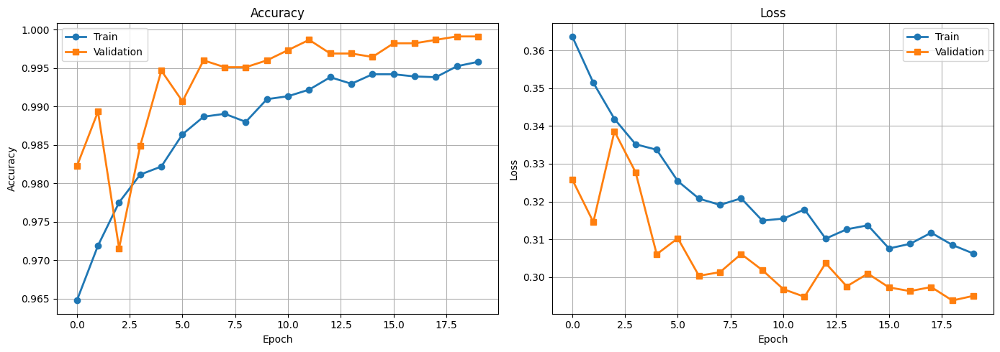

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

####################
# Accuracy
####################

axes[0].plot(
    history["train_acc"],
    marker="o",
    linewidth=2,
    label="Train"
)

axes[0].plot(
    history["val_acc"],
    marker="s",
    linewidth=2,
    label="Validation"
)

axes[0].set_title("Accuracy")

axes[0].set_xlabel("Epoch")

axes[0].set_ylabel("Accuracy")

axes[0].grid(True)

axes[0].legend()

####################
# Loss
####################

axes[1].plot(
    history["train_loss"],
    marker="o",
    linewidth=2,
    label="Train"
)

axes[1].plot(
    history["val_loss"],
    marker="s",
    linewidth=2,
    label="Validation"
)

axes[1].set_title("Loss")

axes[1].set_xlabel("Epoch")

axes[1].set_ylabel("Loss")

axes[1].grid(True)

axes[1].legend()

plt.tight_layout()

plt.show()

In [66]:
import numpy as np
from tqdm.auto import tqdm

y_true = []
y_pred = []
y_prob = []

model.eval()

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.cpu().numpy())

        y_pred.extend(preds.cpu().numpy())

        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

  0%|          | 0/71 [00:00<?, ?it/s]

In [67]:
class_names = [
    "Adenocarcinoma",
    "Benign",
    "Squamous_Cell_Carcinoma"
]
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

                         precision    recall  f1-score   support

         Adenocarcinoma     0.9892    1.0000    0.9946       734
                 Benign     1.0000    1.0000    1.0000       728
Squamous_Cell_Carcinoma     1.0000    0.9898    0.9949       788

               accuracy                         0.9964      2250
              macro avg     0.9964    0.9966    0.9965      2250
           weighted avg     0.9965    0.9964    0.9964      2250



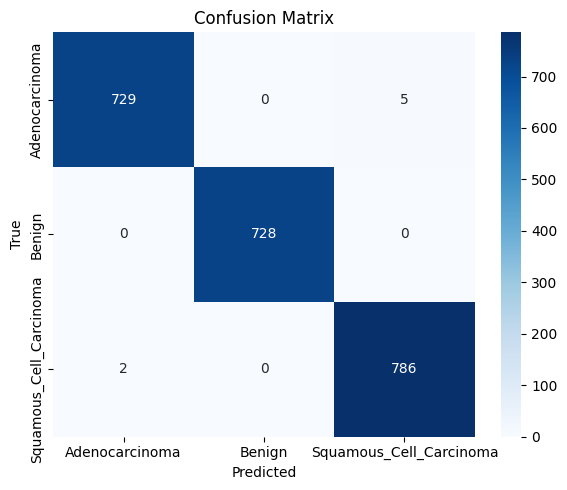

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Confusion Matrix")

plt.tight_layout()

plt.show()

In [83]:
torch.save(model.state_dict(), "/kaggle/working/best_model_lc25000.pth")

print("Model saved successfully!")

Model saved successfully!


In [84]:
import os

print(os.path.exists("/kaggle/working/best_model_lc25000.pth"))

True


**NOW WE TEST ON LUNGHIST700 FOR GENERALISATION** 

In [69]:
import os
from PIL import Image
from torch.utils.data import Dataset

class LungHist700Dataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.transform = transform
        self.samples = []

        class_map = {
            "aca": 0,   # Adenocarcinoma
            "nor": 1,   # Normal (Benign)
            "ssc": 2    # Squamous
        }

        for folder, label in class_map.items():

            folder_path = os.path.join(root_dir, folder)

            for img in os.listdir(folder_path):

                if img.lower().endswith((".jpg",".jpeg",".png")):

                    self.samples.append(
                        (os.path.join(folder_path,img),label)
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self,idx):

        path,label = self.samples[idx]

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image,label

In [70]:
transform = test_dataset.dataset.transform

external_dataset = LungHist700Dataset(
    lung700_path,
    transform=transform
)

In [71]:
from torch.utils.data import DataLoader

external_loader = DataLoader(
    external_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(len(external_dataset))

691


In [72]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    balanced_accuracy_score
)

import numpy as np

model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for images,labels in external_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs,dim=1)

        preds = probs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())

        y_pred.extend(preds.cpu().numpy())

        y_prob.extend(probs.cpu().numpy())

In [73]:
print("="*60)

print("External Validation : LungHist700")

print("="*60)

print(f"Accuracy            : {accuracy_score(y_true,y_pred):.4f}")

print(f"Balanced Accuracy   : {balanced_accuracy_score(y_true,y_pred):.4f}")

print(f"Precision           : {precision_score(y_true,y_pred,average='weighted'):.4f}")

print(f"Recall              : {recall_score(y_true,y_pred,average='weighted'):.4f}")

print(f"F1 Score            : {f1_score(y_true,y_pred,average='weighted'):.4f}")

print(f"MCC                 : {matthews_corrcoef(y_true,y_pred):.4f}")

print(f"Cohen Kappa         : {cohen_kappa_score(y_true,y_pred):.4f}")

External Validation : LungHist700
Accuracy            : 0.5615
Balanced Accuracy   : 0.4907
Precision           : 0.6089
Recall              : 0.5615
F1 Score            : 0.5179
MCC                 : 0.3012
Cohen Kappa         : 0.2821


In [95]:
print(test_dataset.dataset.class_to_idx)

{'adenocarcinoma': 0, 'benign': 1, 'squamous_cell_carcinoma': 2}


In [74]:
print(classification_report(
    y_true,
    y_pred,
    target_names=[
        "Adenocarcinoma",
        "Benign",
        "Squamous Cell Carcinoma"
    ]
))

                         precision    recall  f1-score   support

         Adenocarcinoma       0.51      0.73      0.60       280
                 Benign       0.76      0.09      0.15       151
Squamous Cell Carcinoma       0.62      0.65      0.64       260

               accuracy                           0.56       691
              macro avg       0.63      0.49      0.47       691
           weighted avg       0.61      0.56      0.52       691



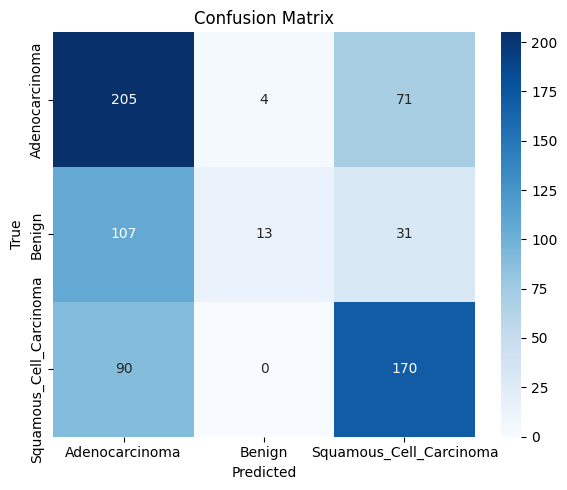

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Confusion Matrix")

plt.tight_layout()

plt.show()

In [101]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/data.csv")

df.head()


,superclass,subclass,resolution,image_id,patient_id
0,aca,bd,40x,901,1
1,aca,bd,40x,902,1
2,aca,bd,40x,903,1
3,aca,bd,40x,904,1
4,aca,bd,40x,905,1


In [102]:
print(df.columns)

Index(['superclass', 'subclass', 'resolution', 'image_id', 'patient_id'], dtype='object')


In [103]:
print(df["resolution"].value_counts())

resolution
20x    359
40x    332
Name: count, dtype: int64


In [104]:
print(pd.crosstab(df["resolution"], df["superclass"]))

superclass  aca  nor  scc
resolution               
20x         146   85  128
40x         134   66  132


In [77]:
model.eval()

ConvNeXtSwinCGMSDGAF(
  (convnext): ConvNeXtBackbone(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2

In [81]:
import torch
import numpy as np
from tqdm import tqdm

model.eval()

features = []
labels = []

with torch.no_grad():
    for images, target in tqdm(external_loader):

        images = images.to(device)

        feat = model.extract_features(images)   # Shape: [B, feature_dim]

        features.append(feat.cpu().numpy())
        labels.append(target.numpy())

features = np.concatenate(features, axis=0)
labels = np.concatenate(labels, axis=0)

print(features.shape)
print(labels.shape)

100%|██████████| 22/22 [00:12<00:00,  1.71it/s]

(691, 256)
(691,)


In [82]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)

embedding = tsne.fit_transform(features)

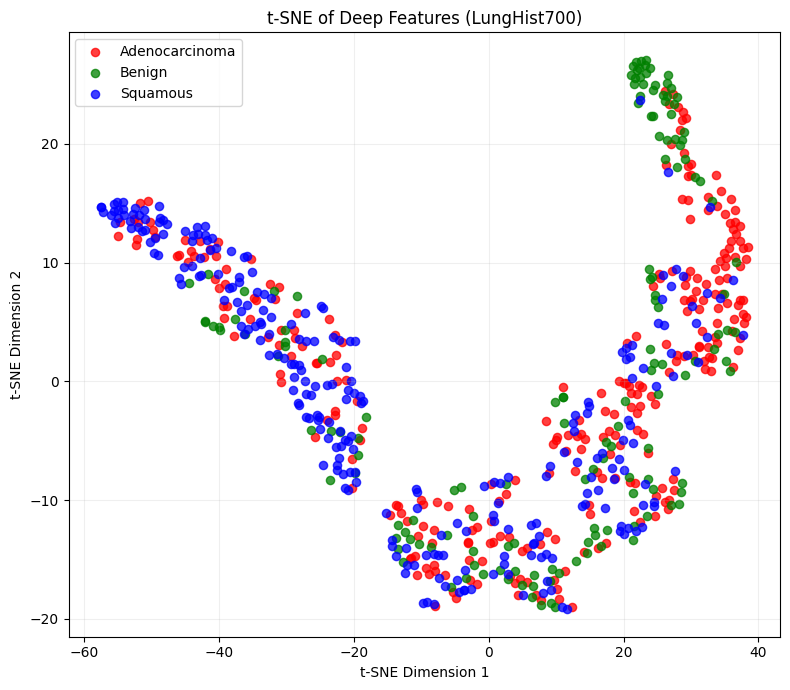

In [83]:
import matplotlib.pyplot as plt

class_names = {
    0: "Adenocarcinoma",
    1: "Benign",
    2: "Squamous"
}

colors = {
    0: "red",
    1: "green",
    2: "blue"
}

plt.figure(figsize=(8, 7))

for cls in sorted(np.unique(labels)):
    idx = labels == cls

    plt.scatter(
        embedding[idx, 0],
        embedding[idx, 1],
        s=35,
        alpha=0.75,
        c=colors[cls],
        label=class_names[cls]
    )

plt.title("t-SNE of Deep Features (LungHist700)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [76]:
import torch
import numpy as np

model.eval()

selected = {}

with torch.no_grad():

    for images, labels in external_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1)

        for i in range(len(labels)):

            true = labels[i].item()
            pred = preds[i].item()

            if true == pred and true not in selected:

                selected[true] = (
                    images[i].cpu(),
                    true
                )

        if len(selected) == 3:
            break

print(selected.keys())

dict_keys([0, 1, 2])


In [77]:
target_layers = [model.fusion.refine[0]]

In [82]:
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

gradcam = GradCAM(
    model=model,
    target_layers=target_layers
)

gradcampp = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)

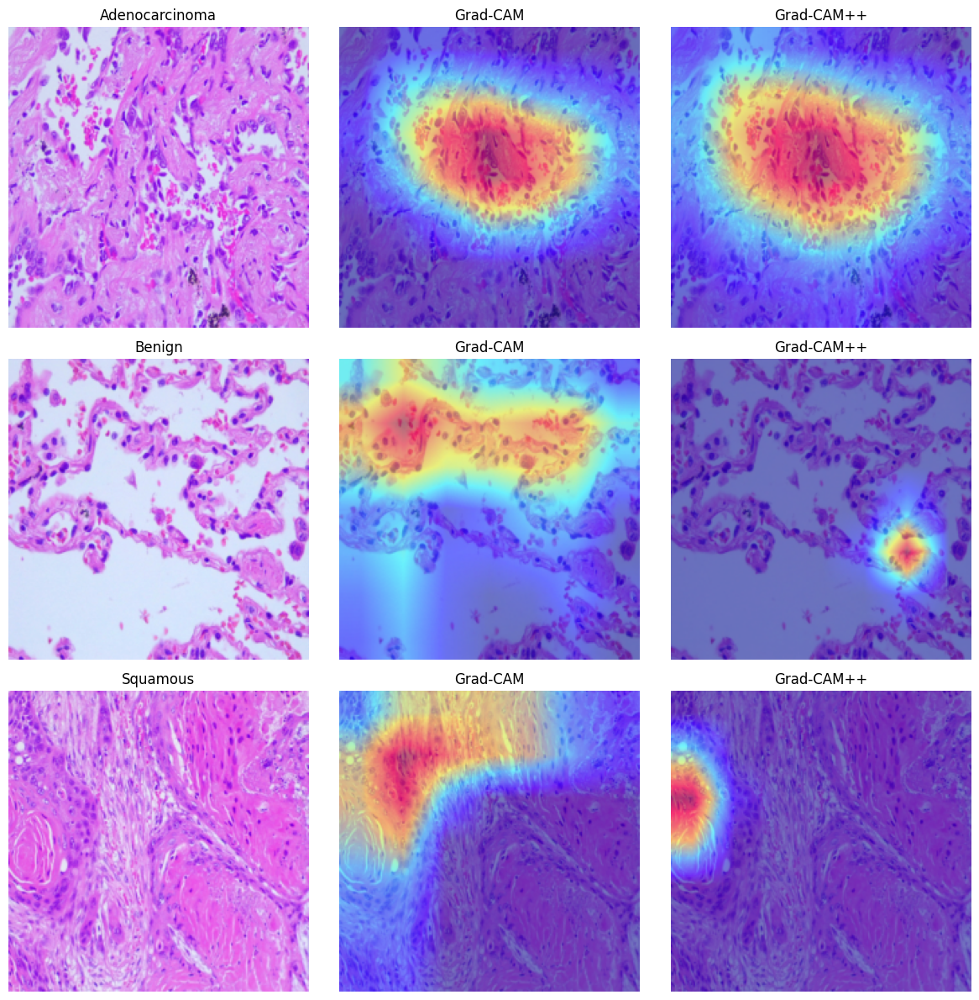

In [83]:
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image

class_names = {
    0: "Adenocarcinoma",
    1: "Benign",
    2: "Squamous"
}

fig, axes = plt.subplots(3,3, figsize=(12,12))

for row, cls in enumerate([0,1,2]):

    image_tensor, label = selected[cls]

    input_tensor = image_tensor.unsqueeze(0).to(device)

    rgb = image_tensor.permute(1,2,0).numpy()
    rgb = (rgb-rgb.min())/(rgb.max()-rgb.min())

    targets=[ClassifierOutputTarget(cls)]

    cam1 = gradcam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    cam2 = gradcampp(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    vis1 = show_cam_on_image(rgb, cam1, use_rgb=True)
    vis2 = show_cam_on_image(rgb, cam2, use_rgb=True)

    axes[row,0].imshow(rgb)
    axes[row,0].set_title(class_names[cls])

    axes[row,1].imshow(vis1)
    axes[row,1].set_title("Grad-CAM")

    axes[row,2].imshow(vis2)
    axes[row,2].set_title("Grad-CAM++")

    for j in range(3):
        axes[row,j].axis("off")

plt.tight_layout()
plt.show()

In [84]:
!pip install -q captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.3 MB/s eta 0:00:00a 0:00:01


In [85]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from captum.attr import IntegratedGradients

In [86]:
ig = IntegratedGradients(model)

class_names = {
    0: "Adenocarcinoma",
    1: "Benign",
    2: "Squamous"
}

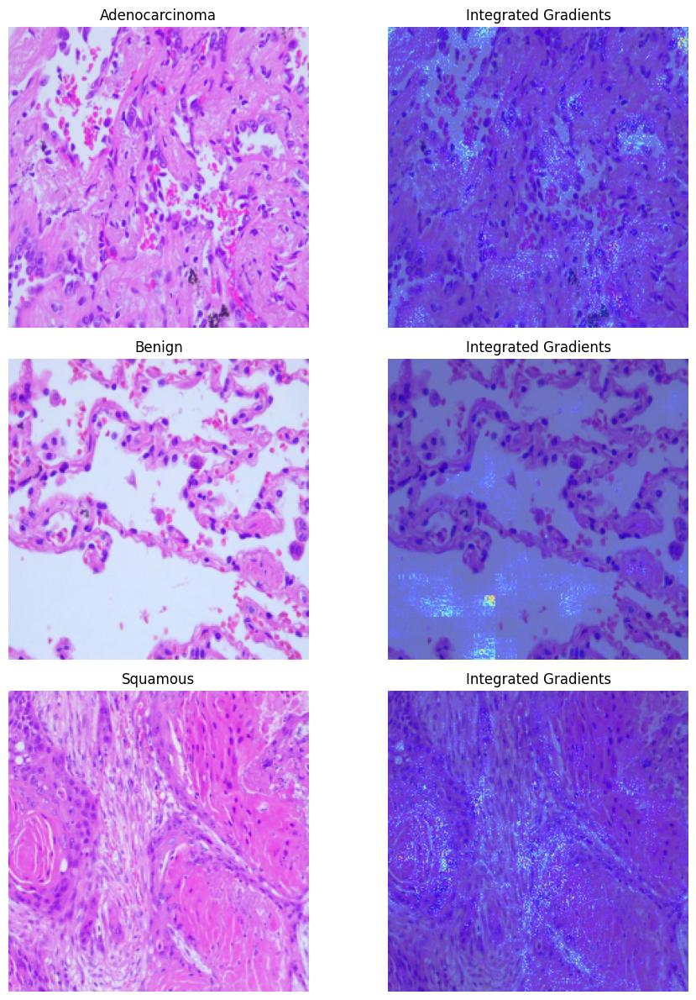

In [87]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for row, cls in enumerate([0, 1, 2]):

    image_tensor, label = selected[cls]

    input_tensor = image_tensor.unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    attributions, delta = ig.attribute(
        input_tensor,
        target=cls,
        baselines=torch.zeros_like(input_tensor),
        n_steps=50,
        return_convergence_delta=True
    )

    attr = attributions.squeeze().cpu().detach().numpy()
    attr = np.transpose(attr, (1, 2, 0))

    # Sum across RGB channels
    attr = np.sum(np.abs(attr), axis=2)

    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

    image = image_tensor.permute(1,2,0).numpy()
    image = (image-image.min())/(image.max()-image.min())

    axes[row,0].imshow(image)
    axes[row,0].set_title(class_names[cls])

    axes[row,1].imshow(image)
    axes[row,1].imshow(attr, cmap='jet', alpha=0.5)
    axes[row,1].set_title("Integrated Gradients")

    axes[row,0].axis("off")
    axes[row,1].axis("off")

plt.tight_layout()
plt.show()

In [88]:
import torch
import gc

torch.cuda.empty_cache()
gc.collect()

device_cpu = torch.device("cpu")

model_cpu = model.to(device_cpu)
model_cpu.eval()

ConvNeXtSwinCGMSDGAF(
  (convnext): ConvNeXtBackbone(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2

In [89]:
import numpy as np
import matplotlib.pyplot as plt

from captum.attr import Occlusion

In [90]:
occlusion = Occlusion(model_cpu)

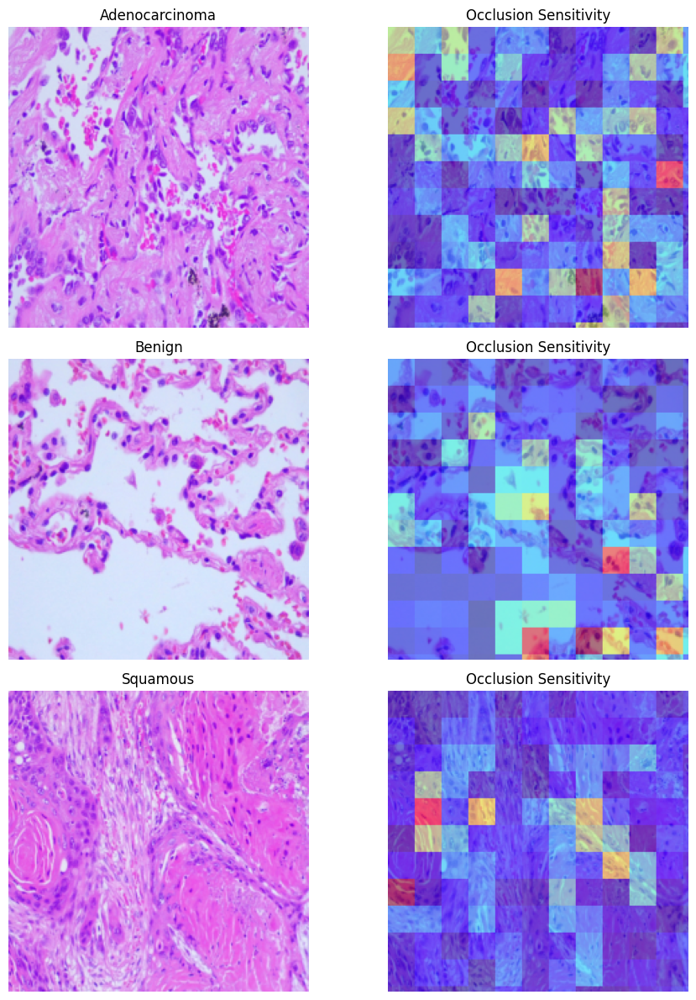

In [92]:
class_names = {
    0: "Adenocarcinoma",
    1: "Benign",
    2: "Squamous"
}

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for row, cls in enumerate([0, 1, 2]):

    image_tensor, label = selected[cls]

    input_tensor = image_tensor.unsqueeze(0).to(device_cpu)

    attr = occlusion.attribute(
        input_tensor,
        target=cls,
        strides=(3, 20, 20),
        sliding_window_shapes=(3, 20, 20),
        baselines=0
    )

    heatmap = attr.squeeze().detach().numpy()
    heatmap = np.sum(np.abs(heatmap), axis=0)

    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    image = image_tensor.permute(1, 2, 0).numpy()
    image = (image - image.min()) / (image.max() - image.min())

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(class_names[cls])

    axes[row, 1].imshow(image)
    axes[row, 1].imshow(heatmap, cmap="jet", alpha=0.5)
    axes[row, 1].set_title("Occlusion Sensitivity")

    axes[row, 0].axis("off")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [93]:
!pip install -q lime

In [94]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from lime import lime_image
from skimage.segmentation import mark_boundaries

In [95]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

ConvNeXtSwinCGMSDGAF(
  (convnext): ConvNeXtBackbone(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2

In [96]:
def predict_fn(images):

    model.eval()

    images = torch.tensor(images, dtype=torch.float32)

    images = images.permute(0,3,1,2).to(device)

    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()

In [97]:
explainer = lime_image.LimeImageExplainer()

class_names = {
    0: "Adenocarcinoma",
    1: "Benign",
    2: "Squamous"
}

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

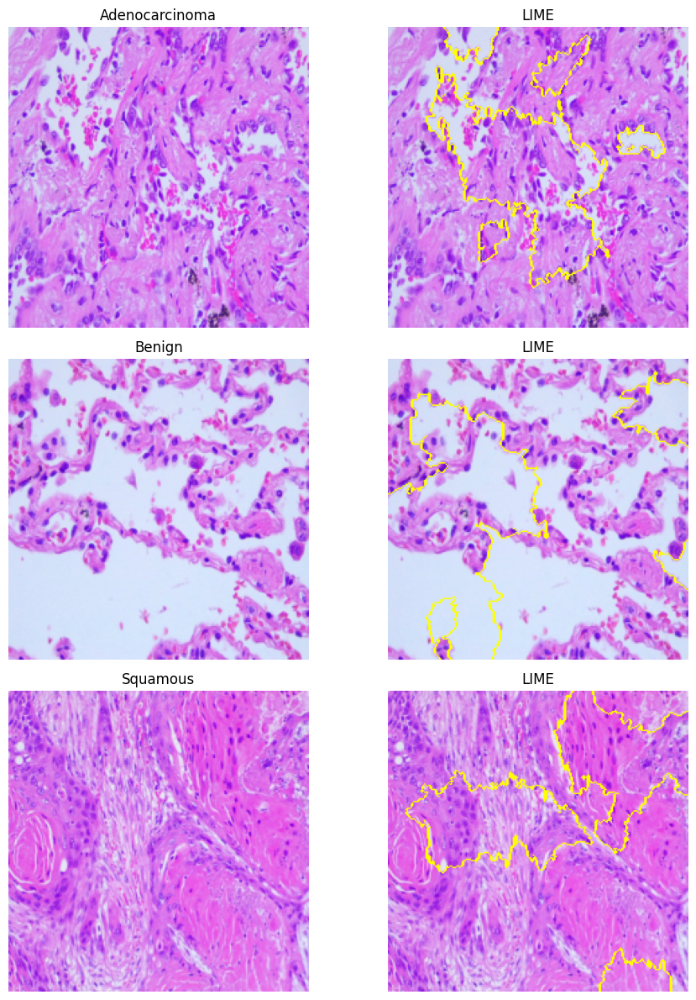

In [98]:
fig, axes = plt.subplots(3,2, figsize=(10,12))

for row, cls in enumerate([0,1,2]):

    image_tensor, label = selected[cls]

    image = image_tensor.permute(1,2,0).numpy()
    image = (image-image.min())/(image.max()-image.min())

    explanation = explainer.explain_instance(
        image.astype(np.float32),
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    lime_image_mask, mask = explanation.get_image_and_mask(
        label=cls,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    axes[row,0].imshow(image)
    axes[row,0].set_title(class_names[cls])

    axes[row,1].imshow(mark_boundaries(lime_image_mask, mask))

    axes[row,1].set_title("LIME")

    axes[row,0].axis("off")
    axes[row,1].axis("off")

plt.tight_layout()
plt.show()

In [99]:
from pytorch_grad_cam import EigenCAM

In [101]:
from pytorch_grad_cam import EigenCAM

cam = EigenCAM(
    model=model,
    target_layers=target_layers
)

In [102]:
grayscale_cam = cam(input_tensor=input_tensor)[0]

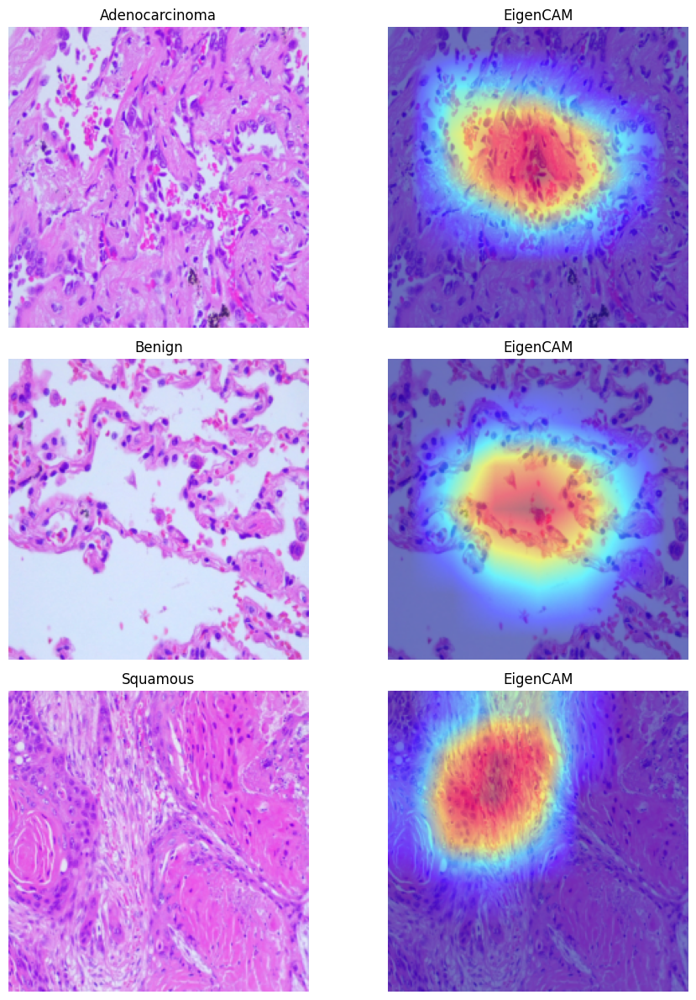

In [103]:
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image

class_names = {
    0: "Adenocarcinoma",
    1: "Benign",
    2: "Squamous"
}

fig, axes = plt.subplots(3,2, figsize=(10,12))

for row, cls in enumerate([0,1,2]):

    image_tensor, label = selected[cls]

    input_tensor = image_tensor.unsqueeze(0).to(device)

    grayscale_cam = cam(
        input_tensor=input_tensor
    )[0]

    rgb_img = image_tensor.permute(1,2,0).numpy()
    rgb_img = (rgb_img-rgb_img.min())/(rgb_img.max()-rgb_img.min())

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    axes[row,0].imshow(rgb_img)
    axes[row,0].set_title(class_names[cls])

    axes[row,1].imshow(visualization)
    axes[row,1].set_title("EigenCAM")

    axes[row,0].axis("off")
    axes[row,1].axis("off")

plt.tight_layout()
plt.show()

In [104]:
from pytorch_grad_cam import HiResCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [105]:
cam = HiResCAM(
    model=model,
    target_layers=target_layers
)

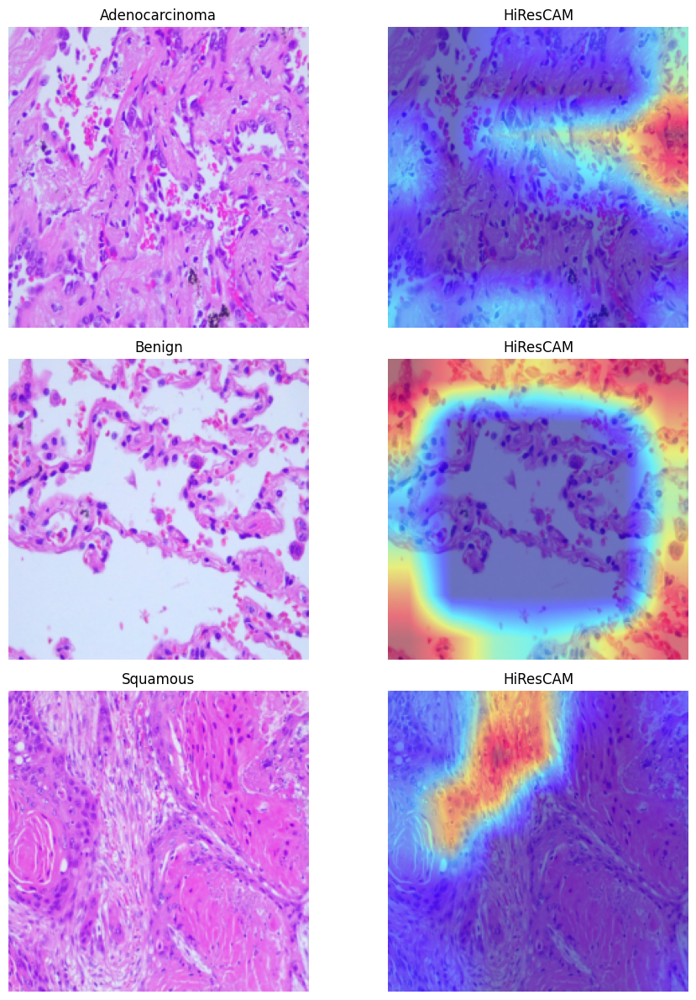

In [106]:
import matplotlib.pyplot as plt
import numpy as np

class_names = {
    0: "Adenocarcinoma",
    1: "Benign",
    2: "Squamous"
}

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for row, cls in enumerate([0, 1, 2]):

    image_tensor, label = selected[cls]

    input_tensor = image_tensor.unsqueeze(0).to(device)

    grayscale_cam = cam(
        input_tensor=input_tensor
    )[0]

    rgb_img = image_tensor.permute(1, 2, 0).cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-8)

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    axes[row, 0].imshow(rgb_img)
    axes[row, 0].set_title(class_names[cls])

    axes[row, 1].imshow(visualization)
    axes[row, 1].set_title("HiResCAM")

    axes[row, 0].axis("off")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import Subset

NUM_FOLDS = 5

targets = np.array(train_dataset_full.targets)
indices = np.arange(len(targets))

skf = StratifiedKFold(
    n_splits=NUM_FOLDS,
    shuffle=True,
    random_state=42
)

In [ ]:
from sklearn.metrics import (
    matthews_corrcoef,
    cohen_kappa_score
)

In [ ]:

from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import DataLoader, Subset
import pandas as pd
import numpy as np
import torch

def run_cross_validation(
    train_dataset_full,
    eval_dataset_full,
    epochs=20,
    n_splits=5
):

    targets = np.array(train_dataset_full.targets)
    indices = np.arange(len(targets))

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    fold_results = []

    for fold, (trainval_idx, test_idx) in enumerate(skf.split(indices, targets), 1):

        print("\n" + "="*70)
        print(f"FOLD {fold}/{n_splits}")
        print("="*70)

        # -------------------------
        # Train / Validation Split
        # -------------------------

        train_idx, val_idx = train_test_split(
            trainval_idx,
            test_size=0.10,
            stratify=targets[trainval_idx],
            random_state=42
        )

        train_dataset = Subset(train_dataset_full, train_idx)
        val_dataset = Subset(eval_dataset_full, val_idx)
        test_dataset = Subset(eval_dataset_full, test_idx)

        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=2,
            pin_memory=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        # -------------------------
        # New Model
        # -------------------------

        model = ConvNeXtSwinCGMSDGAF(
            num_classes=3
        ).to(device)

        freeze_backbones(model)

        criterion = nn.CrossEntropyLoss(
            label_smoothing=0.1
        )

        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-3,
            weight_decay=1e-4
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            T_0=5,
            T_mult=2
        )

        scaler = torch.amp.GradScaler("cuda")

        early_stopping = EarlyStopping(
            patience=7,
            path=f"best_fold_{fold}.pth"
        )

        # -------------------------
        # Training
        # -------------------------

        for epoch in range(epochs):

            if epoch == 5:

                print("\nFine Tuning...\n")

                unfreeze_backbones(model)

                optimizer = torch.optim.AdamW(
                    model.parameters(),
                    lr=1e-4,
                    weight_decay=1e-4
                )

            train_loss, train_acc = train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                scaler,
                device
            )

            metrics = validate(
                model,
                val_loader,
                criterion,
                device
            )

            scheduler.step()

            print(
                f"Epoch {epoch+1:02d}/{epochs} | "
                f"Train Acc {train_acc:.4f} | "
                f"Val Acc {metrics['acc']:.4f} | "
                f"F1 {metrics['f1']:.4f}"
            )

            early_stopping(
                metrics["f1"],
                model
            )

            if early_stopping.early_stop:

                print("Early Stopping")

                break

        # -------------------------
        # Test
        # -------------------------

        
            # -------------------------
        # Test
        # -------------------------

        model.load_state_dict(
            torch.load(
                f"best_fold_{fold}.pth",
                map_location=device
            )
        )

        test_metrics = validate(
            model,
            test_loader,
            criterion,
            device
        )

        mcc = matthews_corrcoef(
            test_metrics["labels"],
            test_metrics["preds"]
        )

        kappa = cohen_kappa_score(
            test_metrics["labels"],
            test_metrics["preds"]
        )

        print("\n" + "-"*70)
        print(f"Fold {fold} Test Performance")
        print("-"*70)

        print(f"Accuracy : {test_metrics['acc']:.4f}")
        print(f"Precision: {test_metrics['precision']:.4f}")
        print(f"Recall   : {test_metrics['recall']:.4f}")
        print(f"F1 Score : {test_metrics['f1']:.4f}")
        print(f"ROC-AUC  : {test_metrics['auc']:.4f}")
        print(f"MCC      : {mcc:.4f}")
        print(f"Kappa    : {kappa:.4f}")

        print("-"*70)

        fold_results.append({

            "Fold": fold,

            "Accuracy": test_metrics["acc"],

            "Precision": test_metrics["precision"],

            "Recall": test_metrics["recall"],

            "F1": test_metrics["f1"],

            "ROC-AUC": test_metrics["auc"],

            "MCC": mcc,

            "Kappa": kappa

        })

        torch.cuda.empty_cache()

        results = pd.DataFrame(fold_results)

    results = results.round(4)

    print("\n")
    print("="*100)
    print("                  5-FOLD CROSS VALIDATION RESULTS")
    print("="*100)

    print(results.to_string(index=False))

    print("="*100)

    summary = pd.DataFrame({

        "Metric":[
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "MCC",
            "Kappa"
        ],

        "Mean":[
            results["Accuracy"].mean(),
            results["Precision"].mean(),
            results["Recall"].mean(),
            results["F1"].mean(),
            results["ROC-AUC"].mean(),
            results["MCC"].mean(),
            results["Kappa"].mean()
        ],

        "Std":[
            results["Accuracy"].std(),
            results["Precision"].std(),
            results["Recall"].std(),
            results["F1"].std(),
            results["ROC-AUC"].std(),
            results["MCC"].std(),
            results["Kappa"].std()
        ]

    })

    summary["Mean ± Std"] = summary.apply(
        lambda x: f"{x['Mean']:.4f} ± {x['Std']:.4f}",
        axis=1
    )

    print("\n")
    print("="*100)
    print("               FINAL CROSS VALIDATION PERFORMANCE")
    print("="*100)

    print(summary[["Metric","Mean ± Std"]].to_string(index=False))

    print("="*100)

    results.to_csv("5Fold_Results.csv", index=False)
    summary.to_csv("5Fold_Summary.csv", index=False)

    return results

In [ ]:
cv_results = run_cross_validation(
    train_dataset_full,
    eval_dataset_full,
    epochs= 10,
    n_splits=5 
)

In [ ]:
def extract_features(self, x):

    conv = self.convnext(x)

    swin = self.swin(x)

    conv = self.align_conv(conv)

    swin = self.align_swin(swin)

    conv = self.ca(conv)

    swin = self.sa(swin)

    fused = self.fusion(conv, swin)

    _, features = self.head(fused, return_features=True)

    return features

In [ ]:
import numpy as np
import torch

features = []
labels = []

model.eval()

with torch.no_grad():

    for images, labs in test_loader:

        images = images.to(device)

        feat = model.extract_features(images)

        features.append(feat.cpu().numpy())

        labels.append(labs.numpy())

features = np.concatenate(features)

labels = np.concatenate(labels)

print(features.shape)

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(

    n_components=2,

    perplexity=30,

    learning_rate="auto",

    init="pca",

    random_state=42

)

embedding = tsne.fit_transform(features)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

class_names = [
    "Adenocarcinoma",
    "Benign",
    "Squamous"
]

colors = [
    "#E41A1C",
    "#377EB8",
    "#4DAF4A"
]

for i in range(3):

    idx = labels == i

    plt.scatter(

        embedding[idx,0],

        embedding[idx,1],

        s=25,

        c=colors[i],

        label=class_names[i],

        alpha=0.75

    )

plt.legend(fontsize=12)

plt.xticks([])

plt.yticks([])

plt.title(
    "t-SNE Visualization of Learned Feature Representations Using the Proposed ConvNeXt–Swin–CGMS–DGAF Network",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "TSNE_ConvNeXt_Swin_CGMS_DAGAF.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
!pip install grad-cam -q

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [ ]:
model = ConvNeXtSwinCGMSDGAF(num_classes=3).to(device)

model.load_state_dict(
    torch.load(
        "best_fold_1.pth",
        map_location=device
    )
)

model.eval()

In [ ]:
target_layers = [model.fusion.refine[0]]

In [ ]:
class_indices = {}

for idx in range(len(test_dataset)):

    img, label = test_dataset[idx]

    if label not in class_indices:
        class_indices[label] = idx

    if len(class_indices) == 3:
        break

print(class_indices)

In [ ]:
def visualize_cam(image_tensor,
                  label,
                  method="gradcam"):

    image = image_tensor.unsqueeze(0).to(device)

    rgb_img = image_tensor.permute(1,2,0).cpu().numpy()

    rgb_img = (rgb_img-rgb_img.min())/(rgb_img.max()-rgb_img.min()+1e-8)

    targets = [
        ClassifierOutputTarget(label)
    ]

    if method=="gradcam":

        cam = GradCAM(
            model=model,
            target_layers=target_layers
        )

    else:

        cam = GradCAMPlusPlus(
            model=model,
            target_layers=target_layers
        )

    grayscale_cam = cam(
        input_tensor=image,
        targets=targets
    )[0]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    return rgb_img, visualization

In [ ]:
classes = {
    0:"Adenocarcinoma",
    1:"Benign",
    2:"Squamous"
}

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12,12)
)

for row, label in enumerate([0,1,2]):

    img,_ = test_dataset[class_indices[label]]

    original, gradcam = visualize_cam(
        img,
        label,
        method="gradcam"
    )

    _, gradcampp = visualize_cam(
        img,
        label,
        method="gradcam++"
    )

    axes[row,0].imshow(original)
    axes[row,0].set_title(
        f"{classes[label]}\nOriginal"
    )

    axes[row,1].imshow(gradcam)
    axes[row,1].set_title("Grad-CAM")

    axes[row,2].imshow(gradcampp)
    axes[row,2].set_title("Grad-CAM++")

    for j in range(3):
        axes[row,j].axis("off")

plt.tight_layout()

plt.savefig(
    "GradCAM_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
!pip install grad-cam -q

In [ ]:
model.eval()

images, labels = next(iter(test_loader))

image = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(image)
    probs = torch.softmax(outputs, dim=1)

class_names = ["Adenocarcinoma", "Benign", "Squamous"]

print("Ground Truth :", class_names[labels[0].item()])
print("Prediction   :", class_names[torch.argmax(probs).item()])

print("\nProbabilities")
for i, c in enumerate(class_names):
    print(f"{c}: {probs[0,i].item():.6f}")

In [ ]:
from pytorch_grad_cam import ScoreCAM

In [ ]:
target_layers = [model.fusion.refine[0]]

scorecam = ScoreCAM(
    model=model,
    target_layers=target_layers
)

In [ ]:
def visualize_scorecam(image_tensor, label):

    image = image_tensor.unsqueeze(0).to(device)

    rgb = image_tensor.permute(1,2,0).cpu().numpy()

    rgb = (rgb-rgb.min())/(rgb.max()-rgb.min()+1e-8)

    targets = [
        ClassifierOutputTarget(label)
    ]

    grayscale_cam = scorecam(
        input_tensor=image,
        targets=targets
    )[0]

    visualization = show_cam_on_image(
        rgb,
        grayscale_cam,
        use_rgb=True
    )

    return rgb, visualization

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

classes = [
    "Adenocarcinoma",
    "Benign",
    "Squamous"
]

for i in range(3):

    img,_ = test_dataset[class_indices[i]]

    original, cam = visualize_scorecam(
        img,
        i
    )

    axes[i].imshow(cam)

    axes[i].set_title(classes[i])

    axes[i].axis("off")

plt.tight_layout()

plt.savefig(
    "ScoreCAM.png",
    dpi=600
)

plt.show()

In [ ]:
!pip install lime -q

In [ ]:
from lime import lime_image

from skimage.segmentation import mark_boundaries

In [ ]:
def predict(images):

    model.eval()

    images = torch.tensor(
        images.transpose(0,3,1,2),
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )

    return probs.cpu().numpy()

In [ ]:
explainer = lime_image.LimeImageExplainer()

In [ ]:
img,label = test_dataset[class_indices[0]]

image = img.permute(1,2,0).numpy()

image = (image-image.min())/(image.max()-image.min())

In [ ]:
explanation = explainer.explain_instance(

    image,

    classifier_fn=predict,

    top_labels=3,

    hide_color=0,

    num_samples=1000
)

In [ ]:
temp, mask = explanation.get_image_and_mask(

    label,

    positive_only=True,

    hide_rest=False,

    num_features=10

)

plt.figure(figsize=(8,8))

plt.imshow(

    mark_boundaries(

        temp,

        mask

    )

)

plt.title("LIME Explanation")

plt.axis("off")

plt.savefig(

    "LIME.png",

    dpi=600

)

plt.show()

In [ ]:
!pip install captum -q

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

In [ ]:
ig = IntegratedGradients(model)

In [ ]:
print(torch.cuda.memory_summary())

In [ ]:
device = torch.device("cpu")

model = ConvNeXtSwinCGMSDGAF(num_classes=3)
model.load_state_dict(torch.load("best_fold_1.pth", map_location="cpu"))
model.eval()

ig = IntegratedGradients(model)

input_tensor = img.unsqueeze(0)

attributions, delta = ig.attribute(
    input_tensor,
    target=label,
    n_steps=20,
    internal_batch_size=5,
    return_convergence_delta=True
)

In [ ]:
plt.savefig(
    "Integrated_Gradients.png",
    dpi=600,
    bbox_inches="tight"
)

In [ ]:
classes = {
    0: "Adenocarcinoma",
    1: "Benign",
    2: "Squamous"
}

for cls in range(3):

    img, label = test_dataset[class_indices[cls]]

    input_tensor = img.unsqueeze(0)

    attributions, delta = ig.attribute(
        input_tensor,
        target=label,
        n_steps=20,
        internal_batch_size=5,
        return_convergence_delta=True
    )

    attr = attributions.squeeze().detach().numpy()
    attr = np.transpose(attr, (1, 2, 0))

    original = img.permute(1, 2, 0).numpy()
    original = (original - original.min()) / (
        original.max() - original.min() + 1e-8
    )

    fig, _ = viz.visualize_image_attr(
        attr,
        original,
        method="heat_map",
        sign="positive",
        show_colorbar=True,
        title=f"Integrated Gradients - {classes[cls]}"
    )

    plt.savefig(
        f"IG_{classes[cls]}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
from captum.attr import Occlusion
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch

In [ ]:
device = torch.device("cpu")

model = ConvNeXtSwinCGMSDGAF(num_classes=3)

model.load_state_dict(
    torch.load(
        "best_fold_1.pth",
        map_location=device
    )
)

model.eval()

occlusion = Occlusion(model)

In [ ]:
img, label = test_dataset[class_indices[0]]

input_tensor = img.unsqueeze(0).to(device)

attributions = occlusion.attribute(

    input_tensor,

    target=label,

    strides=(3,8,8),

    sliding_window_shapes=(3,20,20),

    baselines=0

)

In [ ]:
heatmap = attributions.squeeze().detach().numpy()

heatmap = np.mean(
    np.abs(heatmap),
    axis=0
)

heatmap = (
    heatmap - heatmap.min()
) / (
    heatmap.max() - heatmap.min() + 1e-8
)

In [ ]:
original = img.permute(1,2,0).numpy()

original = (
    original - original.min()
) / (
    original.max() - original.min() + 1e-8
)

heatmap = cv2.resize(
    heatmap,
    (224,224)
)

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(
    heatmap,
    cv2.COLOR_BGR2RGB
)

overlay = (
    0.4 * heatmap / 255.0 +
    0.6 * original
)

overlay = np.clip(
    overlay,
    0,
    1
)

In [ ]:
plt.figure(figsize=(8,8))

plt.imshow(overlay)

plt.title("Occlusion Sensitivity")

plt.axis("off")

plt.tight_layout()

plt.savefig(
    "Occlusion_Sensitivity.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
classes = {
    0: "Adenocarcinoma",
    1: "Benign",
    2: "Squamous"
}

for cls in range(3):

    img, label = test_dataset[class_indices[cls]]

    input_tensor = img.unsqueeze(0)

    attributions = occlusion.attribute(
        input_tensor,
        target=label,
        strides=(3,8,8),
        sliding_window_shapes=(3,20,20),
        baselines=0
    )

    heatmap = attributions.squeeze().detach().numpy()
    heatmap = np.mean(np.abs(heatmap), axis=0)

    heatmap = (
        heatmap - heatmap.min()
    ) / (
        heatmap.max() - heatmap.min() + 1e-8
    )

    original = img.permute(1,2,0).numpy()
    original = (
        original - original.min()
    ) / (
        original.max() - original.min() + 1e-8
    )

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = 0.4 * heatmap / 255.0 + 0.6 * original
    overlay = np.clip(overlay, 0, 1)

    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.title(f"Occlusion Sensitivity - {classes[cls]}")
    plt.axis("off")

    plt.savefig(
        f"Occlusion_{classes[cls]}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
attributions = occlusion.attribute(

    input_tensor,

    target=label,

    strides=(3,4,4),

    sliding_window_shapes=(3,8,8),

    baselines=0

)

In [ ]:
heatmap = cv2.GaussianBlur(
    heatmap,
    (15,15),
    5
)

In [ ]:
heatmap = cv2.applyColorMap(
    np.uint8(255*heatmap),
    cv2.COLORMAP_TURBO
)

In [ ]:
overlay = cv2.addWeighted(
    original.astype(np.float32),
    0.65,
    heatmap.astype(np.float32)/255,
    0.35,
    0
)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(original)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(overlay)
ax[1].set_title("Occlusion Sensitivity")
ax[1].axis("off")

plt.tight_layout()

plt.savefig(
    f"Occlusion_{classes[cls]}_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
plt.figure(figsize=(8,8))

plt.imshow(overlay)

plt.title(
    f"Occlusion Sensitivity - {classes[cls]}",
    fontsize=14
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    f"Occlusion_{classes[cls]}.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
plt.figure(figsize=(8,8))

plt.imshow(overlay)

plt.title("Occlusion Sensitivity - Adenocarcinoma", fontsize=14)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    "Occlusion_Adenocarcinoma.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import torch

class_names = ["Adenocarcinoma", "Benign", "Squamous"]

sample_images = {}
sample_labels = {}

model.eval()

for images, labels in test_loader:

    for i in range(len(labels)):
        label = labels[i].item()

        if label not in sample_images:
            sample_images[label] = images[i].unsqueeze(0)
            sample_labels[label] = label

        if len(sample_images) == 3:
            break

    if len(sample_images) == 3:
        break

print("Collected Images:")
for k in sorted(sample_images.keys()):
    print(f"{class_names[k]} collected.")

In [ ]:
for label in sorted(sample_images.keys()):

    image = sample_images[label].to(device)

    with torch.no_grad():
        output = model(image)
        probs = torch.softmax(output, dim=1)

    pred = torch.argmax(probs, dim=1).item()

    print(f"\nGround Truth : {class_names[label]}")
    print(f"Prediction   : {class_names[pred]}")

    for i, c in enumerate(class_names):
        print(f"{c}: {probs[0][i]:.4f}")

In [ ]:
target_layers = [model.fusion.refine[0]]

In [ ]:
print(type(cam))

In [ ]:
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

rgb_img = image.squeeze(0).permute(1,2,0).cpu().numpy()
rgb_img = rgb_img * std + mean
rgb_img = np.clip(rgb_img, 0, 1)

In [ ]:
gradcam = GradCAM(
    model=model,
    target_layers=target_layers
)

grayscale_cam = gradcam(
    input_tensor=image,
    targets=targets
)

cam_image = show_cam_on_image(
    rgb_img,
    grayscale_cam[0],
    use_rgb=True
)

In [ ]:
image = sample_images[0].to(device)   # Adenocarcinoma

targets = [ClassifierOutputTarget(0)]

grayscale_cam = cam(
    input_tensor=image,
    targets=targets
)[0]

In [ ]:
image = sample_images[0].to(device)

In [ ]:
count = 0

for images, labels in test_loader:

    for i in range(len(labels)):

        if labels[i].item() == 0:      # Adenocarcinoma

            image = images[i].unsqueeze(0).to(device)

            grayscale_cam = cam(
                input_tensor=image,
                targets=[ClassifierOutputTarget(0)]
            )[0]

            rgb_img = image.squeeze(0).cpu().permute(1,2,0).numpy()
            rgb_img = rgb_img * std + mean
            rgb_img = np.clip(rgb_img,0,1)

            visualization = show_cam_on_image(
                rgb_img,
                grayscale_cam,
                use_rgb=True
            )

            plt.figure(figsize=(8,4))

            plt.subplot(1,2,1)
            plt.imshow(rgb_img)
            plt.title(f"Adeno #{count+1}")
            plt.axis("off")

            plt.subplot(1,2,2)
            plt.imshow(visualization)
            plt.title("Grad-CAM")
            plt.axis("off")

            plt.show()

            count += 1

            if count == 5:
                break

    if count == 5:
        break

In [ ]:
with torch.no_grad():
    output = model(image)
    probs = torch.softmax(output, dim=1)

print("Prediction:", class_names[probs.argmax().item()])
print("Confidence:", probs.max().item())

In [ ]:
cam = GradCAMPlusPlus(
    model=model,
    target_layers=[model.fusion.refine[0]]
)

for target_class in range(3):

    count = 0

    print(f"\n===== {class_names[target_class]} =====")

    for images, labels in test_loader:

        for i in range(len(labels)):

            if labels[i].item() != target_class:
                continue

            image = images[i].unsqueeze(0).to(device)

            grayscale_cam = cam(
                input_tensor=image,
                targets=[ClassifierOutputTarget(target_class)]
            )[0]

            rgb_img = image.squeeze(0).cpu().permute(1,2,0).numpy()
            rgb_img = rgb_img * std + mean
            rgb_img = np.clip(rgb_img,0,1)

            visualization = show_cam_on_image(
                rgb_img,
                grayscale_cam,
                use_rgb=True
            )

            plt.figure(figsize=(10,5))

            plt.subplot(1,2,1)
            plt.imshow(rgb_img)
            plt.title(f"{class_names[target_class]} #{count+1}")
            plt.axis("off")

            plt.subplot(1,2,2)
            plt.imshow(visualization)
            plt.title("Grad-CAM++")
            plt.axis("off")

            plt.show()

            count += 1

            if count == 5:
                break

        if count == 5:
            break

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import matplotlib.pyplot as plt
import numpy as np
import torch

# Grad-CAM
cam = GradCAM(
    model=model,
    target_layers=[model.fusion.refine[0]]
)

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

model.eval()

for target_class in range(3):

    count = 0

    print(f"\n================ {class_names[target_class]} ================\n")

    for images, labels in test_loader:

        for i in range(len(labels)):

            if labels[i].item() != target_class:
                continue

            image = images[i].unsqueeze(0).to(device)

            # Prediction
            with torch.no_grad():
                output = model(image)
                probs = torch.softmax(output, dim=1)

            pred = probs.argmax(dim=1).item()
            confidence = probs.max().item()

            # Grad-CAM
            grayscale_cam = cam(
                input_tensor=image,
                targets=[ClassifierOutputTarget(target_class)]
            )[0]

            # Convert image back to RGB
            rgb_img = image.squeeze(0).cpu().permute(1,2,0).numpy()
            rgb_img = rgb_img * std + mean
            rgb_img = np.clip(rgb_img,0,1)

            visualization = show_cam_on_image(
                rgb_img,
                grayscale_cam,
                use_rgb=True
            )

            # Plot
            plt.figure(figsize=(10,5))

            plt.subplot(1,2,1)
            plt.imshow(rgb_img)
            plt.title(f"{class_names[target_class]} #{count+1}")
            plt.axis("off")

            plt.subplot(1,2,2)
            plt.imshow(visualization)
            plt.title(f"Grad-CAM\nPred: {class_names[pred]} ({confidence:.3f})")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

            count += 1

            if count == 5:
                break

        if count == 5:
            break

In [ ]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import matplotlib.pyplot as plt
import numpy as np
import torch

# Grad-CAM++
cam = GradCAMPlusPlus(
    model=model,
    target_layers=[model.fusion.refine[0]]
)

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

model.eval()

for target_class in range(3):

    count = 0

    print(f"\n================ {class_names[target_class]} ================\n")

    for images, labels in test_loader:

        for i in range(len(labels)):

            if labels[i].item() != target_class:
                continue

            image = images[i].unsqueeze(0).to(device)

            # Prediction
            with torch.no_grad():
                output = model(image)
                probs = torch.softmax(output, dim=1)

            pred = probs.argmax(dim=1).item()
            confidence = probs.max().item()

            # Grad-CAM++
            grayscale_cam = cam(
                input_tensor=image,
                targets=[ClassifierOutputTarget(target_class)]
            )[0]

            # Convert image back to RGB
            rgb_img = image.squeeze(0).cpu().permute(1,2,0).numpy()
            rgb_img = rgb_img * std + mean
            rgb_img = np.clip(rgb_img,0,1)

            visualization = show_cam_on_image(
                rgb_img,
                grayscale_cam,
                use_rgb=True
            )

            # Plot
            plt.figure(figsize=(10,5))

            plt.subplot(1,2,1)
            plt.imshow(rgb_img)
            plt.title(f"{class_names[target_class]} #{count+1}")
            plt.axis("off")

            plt.subplot(1,2,2)
            plt.imshow(visualization)
            plt.title(f"Grad-CAM++\nPred: {class_names[pred]} ({confidence:.3f})")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

            count += 1

            if count == 5:
                break

        if count == 5:
            break

In [ ]:
pip install lime

In [ ]:
num_samples=2000
num_features=15

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from lime import lime_image
from skimage.segmentation import mark_boundaries

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

model.eval()

# -------------------------------------------------------
# Prediction function for LIME
# -------------------------------------------------------
def batch_predict(images):

    model.eval()

    images = np.stack(images, axis=0)

    # Normalize
    images = (images - mean) / std

    images = torch.tensor(images, dtype=torch.float32)
    images = images.permute(0,3,1,2).to(device)

    with torch.no_grad():
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

    return probs.cpu().numpy()


explainer = lime_image.LimeImageExplainer()

for target_class in range(3):

    count = 0

    print(f"\n================ {class_names[target_class]} ================\n")

    for images, labels in test_loader:

        for i in range(len(labels)):

            if labels[i].item() != target_class:
                continue

            image_tensor = images[i].unsqueeze(0).to(device)

            # Prediction
            with torch.no_grad():

                output = model(image_tensor)
                probs = F.softmax(output, dim=1)

            pred = probs.argmax(dim=1).item()
            confidence = probs.max().item()

            # Convert back to RGB
            rgb_img = image_tensor.squeeze(0).cpu().permute(1,2,0).numpy()
            rgb_img = rgb_img * std + mean
            rgb_img = np.clip(rgb_img,0,1)

            # LIME
            explanation = explainer.explain_instance(

                rgb_img,

                batch_predict,

                top_labels=3,

                hide_color=0,

                num_samples=2000

            )

            temp, mask = explanation.get_image_and_mask(

                label=pred,

                positive_only=True,

                num_features=15,

                hide_rest=False

            )

            lime_vis = mark_boundaries(temp, mask)

            plt.figure(figsize=(10,5))

            plt.subplot(1,2,1)
            plt.imshow(rgb_img)
            plt.title(f"{class_names[target_class]} #{count+1}")
            plt.axis("off")

            plt.subplot(1,2,2)
            plt.imshow(lime_vis)
            plt.title(f"LIME\nPred: {class_names[pred]} ({confidence:.3f})")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

            count += 1

            if count == 5:
                break

        if count == 5:
            break

In [ ]:
import torch
import torch.nn.functional as F

model.eval()

top_images = {0: [], 1: [], 2: []}

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        confs, preds = probs.max(dim=1)

        for i in range(images.size(0)):

            gt = labels[i].item()
            pred = preds[i].item()
            conf = confs[i].item()

            # Keep only correctly classified images
            if gt == pred:

                top_images[gt].append({
                    "image": images[i].detach().cpu(),
                    "confidence": conf,
                    "prediction": pred
                })

# Sort each class by confidence
for cls in range(3):

    top_images[cls] = sorted(
        top_images[cls],
        key=lambda x: x["confidence"],
        reverse=True
    )[:5]

print("Selected Images")

for cls in range(3):

    print(f"\n{class_names[cls]}")

    for i, sample in enumerate(top_images[cls]):

        print(
            f"Image {i+1}: "
            f"Confidence = {sample['confidence']:.4f}"
        )

In [ ]:
for cls in range(3):

    print(f"\n===== {class_names[cls]} =====")

    for idx, sample in enumerate(top_images[cls]):

        image = sample["image"].unsqueeze(0).to(device)

        pred = sample["prediction"]
        confidence = sample["confidence"]

        grayscale_cam = cam(
            input_tensor=image,
            targets=[ClassifierOutputTarget(pred)]
        )[0]

        rgb_img = image.squeeze().cpu().permute(1,2,0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img,0,1)

        visualization = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True
        )

        plt.figure(figsize=(10,5))

        plt.subplot(1,2,1)
        plt.imshow(rgb_img)
        plt.title(f"{class_names[cls]} #{idx+1}")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(visualization)
        plt.title(f"Grad-CAM\nPred: {class_names[pred]} ({confidence:.3f})")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

In [ ]:
for cls in range(3):

    print(f"\n===== {class_names[cls]} =====")

    for idx, sample in enumerate(top_images[cls]):

        image = sample["image"].unsqueeze(0).to(device)

        pred = sample["prediction"]
        confidence = sample["confidence"]

        grayscale_cam = cam(
            input_tensor=image,
            targets=[ClassifierOutputTarget(pred)]
        )[0]

        rgb_img = image.squeeze().cpu().permute(1, 2, 0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img, 0, 1)

        visualization = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True
        )

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(rgb_img)
        plt.title(f"{class_names[cls]} #{idx+1}")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(visualization)
        plt.title(f"Grad-CAM++\nPred: {class_names[pred]} ({confidence:.3f})")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from lime import lime_image
from skimage.segmentation import mark_boundaries

# -----------------------------
# Mean and Std (ImageNet)
# -----------------------------
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

model.eval()

# -----------------------------
# LIME Prediction Function
# -----------------------------
def batch_predict(images):

    images = np.stack(images, axis=0)

    images = (images - mean) / std

    images = torch.tensor(images, dtype=torch.float32)
    images = images.permute(0, 3, 1, 2).to(device)

    with torch.no_grad():
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

    return probs.cpu().numpy()


explainer = lime_image.LimeImageExplainer()

# -----------------------------
# Explain Top 5 Images
# -----------------------------
for cls in range(3):

    print(f"\n===== {class_names[cls]} =====")

    for idx, sample in enumerate(top_images[cls]):

        image_tensor = sample["image"].unsqueeze(0).to(device)

        pred = sample["prediction"]
        confidence = sample["confidence"]

        # Convert image back to RGB
        rgb_img = image_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img, 0, 1)

        # LIME Explanation
        explanation = explainer.explain_instance(
            rgb_img,
            batch_predict,
            top_labels=3,
            hide_color=0,
            num_samples=2000
        )

        temp, mask = explanation.get_image_and_mask(
            label=pred,
            positive_only=True,
            num_features=15,
            hide_rest=False
        )

        lime_vis = mark_boundaries(temp, mask)

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(rgb_img)
        plt.title(f"{class_names[cls]} #{idx+1}")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(lime_vis)
        plt.title(f"LIME\nPred: {class_names[pred]} ({confidence:.3f})")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

**GRAD CAM++******

In [ ]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
cam = GradCAMPlusPlus(
    model=model,
    target_layers=[model.fusion.refine[0]]
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

model.eval()

# ---------------------------------------
# Grad-CAM++ for Top 5 Images per Class
# ---------------------------------------
for cls in range(3):

    print(f"\n===== {class_names[cls]} =====")

    for idx, sample in enumerate(top_images[cls]):

        image = sample["image"].unsqueeze(0).to(device)

        pred = sample["prediction"]
        confidence = sample["confidence"]

        # Generate Grad-CAM++
        grayscale_cam = cam(
            input_tensor=image,
            targets=[ClassifierOutputTarget(pred)]
        )[0]

        # Convert image back to RGB
        rgb_img = image.squeeze().cpu().permute(1, 2, 0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img, 0, 1)

        # Overlay heatmap
        visualization = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True,
            image_weight=0.45
        )

        plt.figure(figsize=(10,5))

        plt.subplot(1,2,1)
        plt.imshow(rgb_img)
        plt.title(f"{class_names[cls]} #{idx+1}")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(visualization)
        plt.title(
            f"Grad-CAM++\n"
            f"GT: {class_names[cls]}\n"
            f"Pred: {class_names[pred]} ({confidence:.3f})"
        )
        plt.axis("off")

        plt.tight_layout()
        plt.show()

In [ ]:
pip install captum

**Intregated Gradients**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from captum.attr import IntegratedGradients
from scipy.ndimage import gaussian_filter

In [ ]:
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

model.eval()

ig = IntegratedGradients(model)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from captum.attr import IntegratedGradients
from scipy.ndimage import gaussian_filter

# -----------------------------
# ImageNet Mean & Std
# -----------------------------
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

model.eval()

ig = IntegratedGradients(model)

# =====================================================
# Integrated Gradients for Top-5 Best Images
# =====================================================

for cls in range(3):

    print(f"\n===== {class_names[cls]} =====")

    for idx, sample in enumerate(top_images[cls]):

        image = sample["image"].unsqueeze(0).to(device)

        pred = sample["prediction"]
        confidence = sample["confidence"]

        # ---------------------------------------
        # Black baseline
        # ---------------------------------------
        baseline = torch.zeros_like(image)

        # ---------------------------------------
        # Integrated Gradients
        # ---------------------------------------
        attributions = ig.attribute(
            image,
            baselines=baseline,
            target=pred,
            n_steps=100,
            internal_batch_size=5
        )

        # ---------------------------------------
        # Convert attribution
        # ---------------------------------------
        attr = attributions.squeeze().detach().cpu().numpy()

        # CHW -> HWC
        attr = np.transpose(attr, (1, 2, 0))

        # Absolute attribution
        attr = np.abs(attr)

        # RGB -> grayscale
        attr = np.sum(attr, axis=2)

        # Smooth heatmap
        attr = gaussian_filter(attr, sigma=1.5)

        # Keep positive attribution only
        attr = np.maximum(attr, 0)

        # Robust normalization
        p1 = np.percentile(attr, 5)
        p99 = np.percentile(attr, 99)

        attr = (attr - p1) / (p99 - p1 + 1e-8)
        attr = np.clip(attr, 0, 1)

        # ---------------------------------------
        # Original image
        # ---------------------------------------
        rgb_img = image.squeeze().cpu().permute(1, 2, 0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img, 0, 1)

        # ---------------------------------------
        # Plot
        # ---------------------------------------
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(rgb_img)
        plt.title(f"{class_names[cls]} #{idx+1}")
        plt.axis("off")

        plt.subplot(1, 2, 2)

        plt.imshow(rgb_img)
        plt.imshow(
            attr,
            cmap="magma",
            alpha=0.45,
            interpolation="bicubic"
        )

        plt.title(
            f"Integrated Gradients\n"
            f"GT: {class_names[cls]}\n"
            f"Pred: {class_names[pred]} ({confidence:.3f})"
        )

        plt.axis("off")

        plt.tight_layout()
        plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from captum.attr import Occlusion
from scipy.ndimage import gaussian_filter

In [ ]:
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

model.eval()

occlusion = Occlusion(model)


In [ ]:
for cls in range(3):

    print(f"\n===== {class_names[cls]} =====")

    for idx, sample in enumerate(top_images[cls]):

        image = sample["image"].unsqueeze(0).to(device)

        pred = sample["prediction"]
        confidence = sample["confidence"]

        # ----------------------------------------
        # Occlusion Attribution
        # ----------------------------------------
        attributions = occlusion.attribute(
            image,
            target=pred,
            sliding_window_shapes=(3, 12, 12),
            strides=(3, 4, 4),
            baselines=0
        )

        # ----------------------------------------
        # Attribution Map
        # ----------------------------------------
        attr = attributions.squeeze().detach().cpu().numpy()

        # Convert CHW → HWC
        attr = np.transpose(attr, (1,2,0))

        # Absolute attribution
        attr = np.abs(attr)

        # RGB → Gray
        attr = np.sum(attr, axis=2)

        # Smooth map
        attr = gaussian_filter(attr, sigma=2)

        # Keep positive values
        attr = np.maximum(attr,0)

        # Robust normalization
        p1 = np.percentile(attr,5)
        p99 = np.percentile(attr,99)

        attr = (attr-p1)/(p99-p1+1e-8)
        attr = np.clip(attr,0,1)

        # ----------------------------------------
        # Original Image
        # ----------------------------------------
        rgb_img = image.squeeze().cpu().permute(1,2,0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img,0,1)

        # ----------------------------------------
        # Plot
        # ----------------------------------------
        plt.figure(figsize=(10,5))

        plt.subplot(1,2,1)
        plt.imshow(rgb_img)
        plt.title(f"{class_names[cls]} #{idx+1}")
        plt.axis("off")

        plt.subplot(1,2,2)

        plt.imshow(rgb_img)
        plt.imshow(
            attr,
            cmap="inferno",
            alpha=0.45,
            interpolation="bicubic"
        )

        plt.title(
            f"Occlusion Sensitivity\n"
            f"GT: {class_names[cls]}\n"
            f"Pred: {class_names[pred]} ({confidence:.3f})"
        )

        plt.axis("off")

        plt.tight_layout()
        plt.show()
        plt.close()

        del attributions
        del attr
        torch.cuda.empty_cache()

**SCORECAM**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
cam = ScoreCAM(
    model=model,
    target_layers=[model.fusion.refine[0]]
)

In [ ]:
import torch

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

model.eval()

for cls in range(3):

    print(f"\n===== {class_names[cls]} =====")

    for idx, sample in enumerate(top_images[cls]):

        image = sample["image"].unsqueeze(0).to(device)

        pred = sample["prediction"]
        confidence = sample["confidence"]

        # ---------------------------------------
        # Score-CAM
        # ---------------------------------------
        grayscale_cam = cam(
            input_tensor=image,
            targets=[ClassifierOutputTarget(pred)]
        )[0]

        # ---------------------------------------
        # Original Image
        # ---------------------------------------
        rgb_img = image.squeeze().cpu().permute(1, 2, 0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img, 0, 1)

        # ---------------------------------------
        # Overlay
        # ---------------------------------------
        visualization = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True,
            image_weight=0.45
        )

        # ---------------------------------------
        # Plot
        # ---------------------------------------
        plt.figure(figsize=(10,5))

        plt.subplot(1,2,1)
        plt.imshow(rgb_img)
        plt.title(f"{class_names[cls]} #{idx+1}")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(visualization)

        plt.title(
            f"Score-CAM\n"
            f"GT: {class_names[cls]}\n"
            f"Pred: {class_names[pred]} ({confidence:.3f})"
        )

        plt.axis("off")

        plt.tight_layout()
        plt.show()
        plt.close()

        torch.cuda.empty_cache()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
cam = EigenCAM(
    model=model,
    target_layers=[model.fusion.refine[0]]
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ---------------------------------------
# Mean & Std
# ---------------------------------------
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

model.eval()

cam = EigenCAM(
    model=model,
    target_layers=[model.fusion.refine[0]]
)

# ==========================================
# EigenCAM Visualization
# ==========================================

for cls in range(3):

    print(f"\n===== {class_names[cls]} =====")

    for idx, sample in enumerate(top_images[cls]):

        image = sample["image"].unsqueeze(0).to(device)

        pred = sample["prediction"]
        confidence = sample["confidence"]

        # Generate EigenCAM
        grayscale_cam = cam(input_tensor=image)[0]

        # Original Image
        rgb_img = image.squeeze().cpu().permute(1, 2, 0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img, 0, 1)

        # Overlay
        visualization = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True,
            image_weight=0.45
        )

        # Plot
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(rgb_img)
        plt.title(f"{class_names[cls]} #{idx+1}")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(visualization)
        plt.title(
            f"EigenCAM\n"
            f"GT: {class_names[cls]}\n"
            f"Pred: {class_names[pred]} ({confidence:.3f})"
        )
        plt.axis("off")

        plt.tight_layout()
        plt.show()
        plt.close()

        torch.cuda.empty_cache()

In [ ]:
gpu_device = device

# Move model to CPU
model_cpu = model.cpu()

cam = ScoreCAM(
    model=model_cpu,
    target_layers=[model_cpu.fusion.refine[0]]
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

model_cpu.eval()

for cls in range(3):

    print(f"\n===== {class_names[cls]} =====")

    for idx, sample in enumerate(top_images[cls]):

        image = sample["image"].unsqueeze(0).cpu()

        pred = sample["prediction"]
        confidence = sample["confidence"]

        grayscale_cam = cam(
            input_tensor=image,
            targets=[ClassifierOutputTarget(pred)]
        )[0]

        rgb_img = image.squeeze().permute(1,2,0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img,0,1)

        visualization = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True,
            image_weight=0.45
        )

        plt.figure(figsize=(10,5))

        plt.subplot(1,2,1)
        plt.imshow(rgb_img)
        plt.title(f"{class_names[cls]} #{idx+1}")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(visualization)
        plt.title(
            f"ScoreCAM\n"
            f"GT: {class_names[cls]}\n"
            f"Pred: {class_names[pred]} ({confidence:.3f})"
        )
        plt.axis("off")

        plt.tight_layout()
        plt.show()
        plt.close()

new****

In [ ]:
import torch

class_names = ["Adenocarcinoma", "Benign", "Squamous"]

sample_images = {}
sample_labels = {}

model.eval()

for images, labels in test_loader:

    for i in range(len(labels)):
        label = labels[i].item()

        if label not in sample_images:
            sample_images[label] = images[i].unsqueeze(0)
            sample_labels[label] = label

        if len(sample_images) == 3:
            break

    if len(sample_images) == 3:
        break

print("Collected Images:")
for k in sorted(sample_images.keys()):
    print(f"{class_names[k]} collected.")

In [ ]:
for label in sorted(sample_images.keys()):

    image = sample_images[label].to(device)

    with torch.no_grad():
        output = model(image)
        probs = torch.softmax(output, dim=1)

    pred = torch.argmax(probs, dim=1).item()

    print(f"\nGround Truth : {class_names[label]}")
    print(f"Prediction   : {class_names[pred]}")

    for i, c in enumerate(class_names):
        print(f"{c}: {probs[0][i]:.4f}")

In [ ]:
print(grayscale_cam.shape)
print(grayscale_cam.min(), grayscale_cam.max())

In [ ]:
print(model)

In [ ]:
model.eval()

with torch.no_grad():
    output = model(image)

print(output)
print(torch.softmax(output, dim=1))
print("Predicted:", output.argmax(dim=1).item())

In [ ]:
print(torch.is_grad_enabled())

In [ ]:
target_layers = [model.convnext.features[7][-1].block[0]]

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Create GradCAM object
gradcam = GradCAM(
    model=model,
    target_layers=target_layers
)

# Use the predicted class (or 0 if you specifically want class 0)
targets = [ClassifierOutputTarget(0)]

# Compute CAM
grayscale_cam = gradcam(
    input_tensor=image,
    targets=targets
)[0]

print("CAM min:", grayscale_cam.min())
print("CAM max:", grayscale_cam.max())
print("CAM shape:", grayscale_cam.shape)

# Visualize
cam_image = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.imshow(cam_image)
plt.axis("off")
plt.show()

In [ ]:
print(sample_images[0].shape)

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

model.eval()

image = sample_images[0].to(device)

target_layers = [model.convnext.features[7][-1].block[0]]

gradcam = GradCAM(
    model=model,
    target_layers=target_layers
)

with torch.no_grad():
    output = model(image)

pred = output.argmax(dim=1).item()
print("Prediction:", pred)

targets = [ClassifierOutputTarget(pred)]

grayscale_cam = gradcam(
    input_tensor=image,
    targets=targets
)[0]

print(grayscale_cam.min(), grayscale_cam.max())

cam_image = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.imshow(cam_image)
plt.axis("off")
plt.show()

In [ ]:
import torch
import torch.nn.functional as F

model.eval()

class_names = ["adenocarcinoma", "benign", "squamous_cell_carcinoma"]

top_images = {0: [], 1: [], 2: []}

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        confs, preds = probs.max(dim=1)

        for i in range(images.size(0)):

            gt = labels[i].item()
            pred = preds[i].item()
            conf = confs[i].item()

            # keep only correctly classified images
            if gt == pred:

                top_images[gt].append({
                    "image": images[i].unsqueeze(0).cpu(),
                    "confidence": conf,
                    "prediction": pred
                })

for cls in top_images:
    top_images[cls] = sorted(
        top_images[cls],
        key=lambda x: x["confidence"],
        reverse=True
    )[:5]

In [ ]:
for cls in range(3):

    print(f"\n{class_names[cls]}")

    for i, sample in enumerate(top_images[cls]):

        print(
            f"Top {i+1}: {sample['confidence']*100:.2f}%"
        )

In [ ]:
sample = top_images[0][2]

image = sample["image"].to(device)

confidence = sample["confidence"]

pred = sample["prediction"]

In [ ]:
targets = [ClassifierOutputTarget(pred)]

grayscale_cam = gradcam(
    input_tensor=image,
    targets=targets
)[0]

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(cam_image)

plt.title(
    f"Adenocarcinoma\nConfidence: {confidence*100:.2f}%"
)

plt.axis("off")
plt.show()

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

model.eval()

class_names = [
    "Adenocarcinoma",
    "Benign",
    "Squamous Cell Carcinoma"
]

top5 = {0: [], 1: [], 2: []}

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)

        confs, preds = probs.max(dim=1)

        for i in range(images.size(0)):

            gt = labels[i].item()
            pred = preds[i].item()
            conf = confs[i].item()

            # Only correctly classified images
            if gt == pred:

                top5[gt].append({
                    "image": images[i].cpu(),
                    "confidence": conf
                })

# Keep only Top-5 confidence images
for cls in top5:

    top5[cls] = sorted(
        top5[cls],
        key=lambda x: x["confidence"],
        reverse=True
    )[:5]

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(18, 11))

for cls in range(3):

    for j in range(5):

        sample = top5[cls][j]

        img = sample["image"].permute(1,2,0).numpy()

        # Undo normalization if required
        img = img * std + mean
        img = img.clip(0,1)

        axes[cls,j].imshow(img)

        axes[cls,j].set_title(
            f"{sample['confidence']*100:.2f}%",
            fontsize=11
        )

        axes[cls,j].axis("off")

    axes[cls,0].set_ylabel(
        class_names[cls],
        fontsize=14,
        rotation=90
    )

plt.tight_layout()
plt.show()

In [ ]:
selected_images = top5

In [ ]:
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import matplotlib.pyplot as plt
import numpy as np
import torch

In [ ]:
target_layers = [model.convnext.features[7][-1].block[0]]

In [ ]:
gradcam = GradCAM(
    model=model,
    target_layers=target_layers
)

gradcam_pp = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)

In [ ]:
class_names = [
    "Adenocarcinoma",
    "Benign",
    "Squamous Cell Carcinoma"
]

fig, axes = plt.subplots(3, 5, figsize=(18, 12))

for cls in range(3):

    for j in range(5):

        sample = top5[cls][j]

        image = sample["image"].unsqueeze(0).to(device)

        confidence = sample["confidence"]

        targets = [ClassifierOutputTarget(cls)]

        grayscale_cam = gradcam(
            input_tensor=image,
            targets=targets
        )[0]

        rgb_img = sample["image"].permute(1,2,0).numpy()

        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img,0,1)

        cam_image = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True
        )

        axes[cls,j].imshow(cam_image)

        axes[cls,j].set_title(
            f"{confidence*100:.2f}%"
        )

        axes[cls,j].axis("off")

    axes[cls,0].set_ylabel(
        class_names[cls],
        fontsize=13
    )

plt.tight_layout()

plt.show()

In [ ]:
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

gradcam = GradCAM(
    model=model,
    target_layers=target_layers
)

gradcam_pp = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)

class_names = [
    "Adenocarcinoma",
    "Benign",
    "Squamous Cell Carcinoma"
]

fig, axes = plt.subplots(3, 15, figsize=(34, 10))

for cls in range(3):

    for j in range(5):

        sample = top5[cls][j]

        image = sample["image"].unsqueeze(0).to(device)

        confidence = sample["confidence"]

        targets = [ClassifierOutputTarget(cls)]

        # Original image
        rgb_img = sample["image"].permute(1,2,0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img,0,1)

        # GradCAM
        grayscale_cam = gradcam(
            input_tensor=image,
            targets=targets
        )[0]

        cam_image = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True
        )

        # GradCAM++
        grayscale_cam_pp = gradcam_pp(
            input_tensor=image,
            targets=targets
        )[0]

        campp_image = show_cam_on_image(
            rgb_img,
            grayscale_cam_pp,
            use_rgb=True
        )

        col = j * 3

        # Original
        axes[cls, col].imshow(rgb_img)
        axes[cls, col].set_title(
            f"Original\n{confidence*100:.2f}%",
            fontsize=9
        )
        axes[cls, col].axis("off")

        # GradCAM
        axes[cls, col+1].imshow(cam_image)
        axes[cls, col+1].set_title(
            "GradCAM",
            fontsize=9
        )
        axes[cls, col+1].axis("off")

        # GradCAM++
        axes[cls, col+2].imshow(campp_image)
        axes[cls, col+2].set_title(
            "GradCAM++",
            fontsize=9
        )
        axes[cls, col+2].axis("off")

    axes[cls,0].set_ylabel(
        class_names[cls],
        fontsize=14
    )

plt.tight_layout()

plt.savefig(
    "GradCAM_GradCAMpp_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import matplotlib.pyplot as plt
import numpy as np

# Initialize CAM methods
gradcam = GradCAM(
    model=model,
    target_layers=target_layers
)

gradcam_pp = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)

class_names = [
    "Adenocarcinoma",
    "Benign",
    "Squamous Cell Carcinoma"
]

fig, axes = plt.subplots(3, 15, figsize=(36, 12))

for cls in range(3):

    for j in range(5):

        sample = top5[cls][j]

        image = sample["image"].unsqueeze(0).to(device)
        confidence = sample["confidence"]

        targets = [ClassifierOutputTarget(cls)]

        # ---------------- Original Image ----------------
        rgb_img = sample["image"].permute(1, 2, 0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img, 0, 1)

        # ---------------- Grad-CAM ----------------
        grayscale_cam = gradcam(
            input_tensor=image,
            targets=targets
        )[0]

        cam_image = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True
        )

        # ---------------- Grad-CAM++ ----------------
        grayscale_cam_pp = gradcam_pp(
            input_tensor=image,
            targets=targets
        )[0]

        campp_image = show_cam_on_image(
            rgb_img,
            grayscale_cam_pp,
            use_rgb=True
        )

        col = j * 3

        # ================= Original =================
        axes[cls, col].imshow(rgb_img)
        axes[cls, col].set_title(
            f"{class_names[cls]}\nOriginal\nConf: {confidence*100:.2f}%",
            fontsize=8,
            fontweight="bold"
        )
        axes[cls, col].axis("off")

        # ================= Grad-CAM =================
        axes[cls, col+1].imshow(cam_image)
        axes[cls, col+1].set_title(
            f"{class_names[cls]}\nGrad-CAM",
            fontsize=8,
            fontweight="bold"
        )
        axes[cls, col+1].axis("off")

        # ================= Grad-CAM++ =================
        axes[cls, col+2].imshow(campp_image)
        axes[cls, col+2].set_title(
            f"{class_names[cls]}\nGrad-CAM++",
            fontsize=8,
            fontweight="bold"
        )
        axes[cls, col+2].axis("off")

# Row labels
for cls in range(3):
    axes[cls, 0].set_ylabel(
        class_names[cls],
        fontsize=14,
        fontweight="bold",
        rotation=90
    )

plt.tight_layout()

plt.savefig(
    "GradCAM_GradCAMpp_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
!pip install captum

In [ ]:
pip install captum

In [ ]:
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
ig = IntegratedGradients(model)

In [ ]:
import numpy as np

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

In [ ]:
cpu_device = torch.device("cpu")

# Move model to CPU
model = model.to(cpu_device)
model.eval()

# Recreate Integrated Gradients on CPU
ig = IntegratedGradients(model)

In [ ]:
fig, axes = plt.subplots(3, 10, figsize=(28, 12))

for cls in range(3):

    for j in range(5):

        sample = top5[cls][j]

        # Move image to CPU
        image = sample["image"].unsqueeze(0).to(cpu_device)

        confidence = sample["confidence"]

        # Original image (denormalized)
        rgb_img = sample["image"].permute(1, 2, 0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img, 0, 1)

        # Integrated Gradients
        attributions, delta = ig.attribute(
            image,
            target=cls,
            baselines=torch.zeros_like(image),
            n_steps=25,
            return_convergence_delta=True
        )

        attr = attributions.squeeze().detach().numpy()
        attr = np.transpose(attr, (1, 2, 0))

        # Aggregate channels
        attr = np.mean(np.abs(attr), axis=2)

        # Normalize
        attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

        col = j * 2

        # Original image
        axes[cls, col].imshow(rgb_img)
        axes[cls, col].set_title(
            f"{class_names[cls]}\nOriginal\nConf: {confidence*100:.2f}%",
            fontsize=8,
            fontweight="bold"
        )
        axes[cls, col].axis("off")

        # Integrated Gradients
        axes[cls, col + 1].imshow(rgb_img)
        axes[cls, col + 1].imshow(
            attr,
            cmap="jet",
            alpha=0.55
        )
        axes[cls, col + 1].set_title(
            f"{class_names[cls]}\nIntegrated Gradients",
            fontsize=8,
            fontweight="bold"
        )
        axes[cls, col + 1].axis("off")

        # Free memory
        del attributions

plt.tight_layout()

plt.savefig(
    "IntegratedGradients_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from captum.attr import Occlusion

model.eval()
occlusion = Occlusion(model)

In [ ]:
fig, axes = plt.subplots(3, 10, figsize=(28, 12))

for cls in range(3):

    for j in range(5):

        sample = top5[cls][j]

        image = sample["image"].unsqueeze(0).to(cpu_device)   # or device if using GPU
        confidence = sample["confidence"]

        # Original image (denormalize)
        rgb_img = sample["image"].permute(1, 2, 0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img, 0, 1)

        # Occlusion Sensitivity
        attributions = occlusion.attribute(
            image,
            target=cls,
            strides=(3, 28, 28),
            sliding_window_shapes=(3, 28, 28),
            baselines=0
        )

        attr = attributions.squeeze().detach().cpu().numpy()
        attr = np.transpose(attr, (1, 2, 0))

        # Aggregate channels
        attr = np.mean(np.abs(attr), axis=2)

        # Normalize
        attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

        col = j * 2

        # Original
        axes[cls, col].imshow(rgb_img)
        axes[cls, col].set_title(
            f"{class_names[cls]}\nOriginal\nConf: {confidence*100:.2f}%",
            fontsize=8,
            fontweight="bold"
        )
        axes[cls, col].axis("off")

        # Occlusion
        axes[cls, col+1].imshow(rgb_img)
        axes[cls, col+1].imshow(
            attr,
            cmap="jet",
            alpha=0.55
        )
        axes[cls, col+1].set_title(
            f"{class_names[cls]}\nOcclusion",
            fontsize=8,
            fontweight="bold"
        )
        axes[cls, col+1].axis("off")

        del attributions

plt.tight_layout()

plt.savefig(
    "OcclusionSensitivity_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [ ]:
explainer = lime_image.LimeImageExplainer()

In [ ]:
import torch
import numpy as np

def predict_fn(images):

  cpu_device = torch.device("cpu")

# Ensure model is on CPU
model = model.to(cpu_device)
model.eval()

mean_t = torch.tensor(mean, dtype=torch.float32).view(1, 3, 1, 1)
std_t  = torch.tensor(std, dtype=torch.float32).view(1, 3, 1, 1)

def predict_fn(images):

    # images: (N, H, W, C), float32 in [0,1]
    batch = torch.from_numpy(images).permute(0, 3, 1, 2).float()

    # Normalize
    batch = (batch - mean_t) / std_t

    # Keep everything on CPU
    batch = batch.to(cpu_device)

    with torch.no_grad():
        logits = model(batch)
        probs = torch.softmax(logits, dim=1)

    return probs.numpy()


    

In [ ]:
from skimage.segmentation import slic, mark_boundaries

# Faster SLIC segmentation
segmenter = lambda x: slic(
    x,
    n_segments=80,
    compactness=10,
    sigma=1,
    start_label=1
)

fig, axes = plt.subplots(3, 10, figsize=(28, 12))

for cls in range(3):

    for j in range(5):

        sample = top5[cls][j]

        confidence = sample["confidence"]

        # Denormalize image
        rgb_img = sample["image"].permute(1, 2, 0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img, 0, 1).astype(np.float32)

        # LIME explanation
        explanation = explainer.explain_instance(
            image=rgb_img,
            classifier_fn=predict_fn,
            top_labels=3,
            hide_color=0,
            num_samples=300,        # Reduced from 1000
            batch_size=64,          # Faster inference
            segmentation_fn=segmenter
        )

        lime_img, mask = explanation.get_image_and_mask(
            label=cls,
            positive_only=True,
            hide_rest=False,
            num_features=8,         # Reduced from 10
            min_weight=0.01
        )

        lime_vis = mark_boundaries(lime_img, mask)

        col = j * 2

        # Original image
        axes[cls, col].imshow(rgb_img)
        axes[cls, col].set_title(
            f"{class_names[cls]}\nOriginal\nConf: {confidence*100:.2f}%",
            fontsize=8,
            fontweight="bold"
        )
        axes[cls, col].axis("off")

        # LIME explanation
        axes[cls, col + 1].imshow(lime_vis)
        axes[cls, col + 1].set_title(
            f"{class_names[cls]}\nLIME",
            fontsize=8,
            fontweight="bold"
        )
        axes[cls, col + 1].axis("off")

plt.tight_layout()

plt.savefig(
    "LIME_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
!pip install grad-cam

In [ ]:
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np
import torch

In [ ]:
target_layers = [model.convnext.features[-1]]

In [ ]:
print(model.convnext)

In [ ]:
cam = EigenCAM(
    model=model,
    target_layers=target_layers
)

In [ ]:
fig, axes = plt.subplots(3, 10, figsize=(28, 12))

for cls in range(3):

    for j in range(5):

        sample = top5[cls][j]

        confidence = sample["confidence"]

        input_tensor = sample["image"].unsqueeze(0).to(device)

        rgb_img = sample["image"].permute(1, 2, 0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img, 0, 1)

        grayscale_cam = cam(
            input_tensor=input_tensor
        )[0]

        cam_image = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True
        )

        col = j * 2

        # Original
        axes[cls, col].imshow(rgb_img)
        axes[cls, col].set_title(
            f"{class_names[cls]}\nOriginal\nConf: {confidence*100:.2f}%",
            fontsize=8,
            fontweight="bold"
        )
        axes[cls, col].axis("off")

        # Eigen-CAM
        axes[cls, col + 1].imshow(cam_image)
        axes[cls, col + 1].set_title(
            f"{class_names[cls]}\nEigen-CAM",
            fontsize=8,
            fontweight="bold"
        )
        axes[cls, col + 1].axis("off")

plt.tight_layout()

plt.savefig(
    "EigenCAM_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from pytorch_grad_cam import HiResCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
target_layers = [model.convnext.features[-1]]

cam = HiResCAM(
    model=model,
    target_layers=target_layers
)

In [ ]:
fig, axes = plt.subplots(3, 10, figsize=(28, 12))

for cls in range(3):

    for j in range(5):

        sample = top5[cls][j]

        confidence = sample["confidence"]

        input_tensor = sample["image"].unsqueeze(0).to(device)

        rgb_img = sample["image"].permute(1,2,0).numpy()
        rgb_img = rgb_img * std + mean
        rgb_img = np.clip(rgb_img, 0, 1)

        grayscale_cam = cam(
            input_tensor=input_tensor
        )[0]

        cam_image = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True
        )

        col = j * 2

        # Original
        axes[cls, col].imshow(rgb_img)
        axes[cls, col].set_title(
            f"{class_names[cls]}\nOriginal\nConf: {confidence*100:.2f}%",
            fontsize=8,
            fontweight="bold"
        )
        axes[cls, col].axis("off")

        # HiResCAM
        axes[cls, col + 1].imshow(cam_image)
        axes[cls, col + 1].set_title(
            f"{class_names[cls]}\nHiResCAM",
            fontsize=8,
            fontweight="bold"
        )
        axes[cls, col + 1].axis("off")

plt.tight_layout()

plt.savefig(
    "HiResCAM_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import torch

cpu_device = torch.device("cpu")

# Move model to CPU
model = model.to(cpu_device)

# Enable gradients
for p in model.parameters():
    p.requires_grad_(True)

model.eval()

print(next(model.parameters()).device)         # cpu
print(next(model.parameters()).requires_grad)  # True

In [ ]:
from pytorch_grad_cam import HiResCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layers = [model.convnext.features[-1][-1]]

cam = HiResCAM(
    model=model,
    target_layers=target_layers
)